# Integrative Challenge M4 - Intelligent Multi-Agent Solution
## AGV fleet for the e80 Group logistics challenge

**Team:** .gitignore

---


<br>

**The question to answer:**

> Does the proposed intelligent strategy improve the performance of the Multi-agent system?

The short answer is yes for throughput, mission time,
distance and run-flat events, and no for AGV utilisation and replanning effort.


## Dependencies

In [ ]:
!pip install agentpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 10.6 MB/s eta 0:00:00


In [ ]:
import time
import random
from collections import deque, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import agentpy as ap
from matplotlib.patches import Rectangle, Patch, FancyArrowPatch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=1, suppress=True)
print("numpy", np.__version__, "| pandas", pd.__version__, "| agentpy", ap.__version__)

numpy 2.1.3 | pandas 2.2.3 | agentpy 0.1.5


---
# Environment

A 48 x 30 m distribution centre on a 1 m grid, described by two structures built from one
parameter dictionary P:

* a **list of elements** `(id, kind, x, y, w, h)` - racks, production lines, docks, chargers, walls, obstacles
* an **occupancy grid** (`numpy int8`), from which the traversable mask is `walkable = grid == FREE`.

Pallet positions are kept in a separate list because they are points inside zones, not solid
blocks, an AGV always stops on the adjacent aisle cell, never on top of the load.


## 1. Coordinate system

In [ ]:
FREE, WALL, PRODUCTION, RACK, DOCK, CHARGER, OBSTACLE = range(7)

CODE = {"wall": WALL, "production": PRODUCTION, "rack": RACK,
        "dock": DOCK, "charger": CHARGER, "obstacle": OBSTACLE}

## 2. Layout parameters

In [ ]:
P = dict(
    width=48, height=30,

    n_lines=3, line_x=2, line_y0=4, line_w=9, line_h=3, line_pitch=8, line_pallets=3,

    rack_x0=18, rack_y0=3, rack_cols=3, rack_rows=2, rack_w=4, rack_h=10,
    aisle_x=3, aisle_y=4, slot_pitch=2,

    n_docks=3, dock_y0=3, dock_w=4, dock_h=5, dock_pitch=9, dock_pallets=2,

    n_chargers=3, charger_x0=9, charger_y=1, charger_w=2, charger_h=2, charger_pitch=4,

    columns=[(14, 8), (14, 15), (14, 22), (38, 8), (38, 15), (38, 22)],
    zones=[(1, 1, 6, 2, "Maintenance room"), (20, 27, 6, 2, "Offices / QC")],
)

## 3. Building the environment

In [ ]:
def build(P):
    elements, pallets = [], []
    add = lambda i, k, x, y, w, h, lab="": elements.append(
        dict(id=i, kind=k, x=x, y=y, w=w, h=h, label=lab))
    slot = lambda i, g, x, y: pallets.append(dict(id=i, group=g, x=x, y=y))

    add("WALL-S", "wall", 0, 0, P["width"], 1)
    add("WALL-N", "wall", 0, P["height"] - 1, P["width"], 1)
    add("WALL-W", "wall", 0, 1, 1, P["height"] - 2)
    add("WALL-E", "wall", P["width"] - 1, 1, 1, P["height"] - 2)

    for i in range(P["n_lines"]):
        y = P["line_y0"] + i * P["line_pitch"]
        add(f"PL-{i+1:02d}", "production", P["line_x"], y, P["line_w"], P["line_h"])
        for k in range(P["line_pallets"]):
            slot(f"PLB-{i+1:02d}-{k+1}", "production", P["line_x"] + P["line_w"], y + k)

    for col in range(P["rack_cols"]):
        for row in range(P["rack_rows"]):
            x = P["rack_x0"] + col * (P["rack_w"] + P["aisle_x"])
            y = P["rack_y0"] + row * (P["rack_h"] + P["aisle_y"])
            rid = f"R-{col+1}{row+1}"
            add(rid, "rack", x, y, P["rack_w"], P["rack_h"])
            for side, sx in (("W", x), ("E", x + P["rack_w"] - 1)):
                for k, sy in enumerate(range(y, y + P["rack_h"], P["slot_pitch"])):
                    slot(f"{rid}-{side}{k+1}", "rack", sx, sy)

    dx = P["width"] - 1 - P["dock_w"]
    for i in range(P["n_docks"]):
        y = P["dock_y0"] + i * P["dock_pitch"]
        add(f"DK-{i+1:02d}", "dock", dx, y, P["dock_w"], P["dock_h"])
        for k in range(P["dock_pallets"]):
            slot(f"DKS-{i+1:02d}-{k+1}", "dock", dx - 2, y + 1 + 2 * k)

    for i in range(P["n_chargers"]):
        add(f"CH-{i+1:02d}", "charger", P["charger_x0"] + i * P["charger_pitch"],
            P["charger_y"], P["charger_w"], P["charger_h"])

    for x, y in P["columns"]:
        add(f"COL-{x}-{y}", "obstacle", x, y, 1, 1)
    for j, (x, y, w, h, lab) in enumerate(P["zones"]):
        add(f"OBS-{j+1:02d}", "obstacle", x, y, w, h, lab)

    grid = np.full((P["height"], P["width"]), FREE, dtype=np.int8)
    for e in elements:
        grid[e["y"]:e["y"] + e["h"], e["x"]:e["x"] + e["w"]] = CODE[e["kind"]]

    return elements, pallets, grid

In [ ]:
elements, pallets, grid = build(P)
walkable = grid == FREE

print(f"Space: {P['width']} x {P['height']} m")
print(f"Traversable area: {walkable.sum()} m^2 "
      f"({walkable.mean():.0%} of the floor)")
print(f"Elements: {len(elements)}  ·  pallet positions: {len(pallets)}")
print("\nExample element E_i = (x, y, w, h):", elements[5])

Space: 48 x 30 m
Traversable area: 865 m^2 (60% of the floor)
Elements: 27  ·  pallet positions: 75

Example element E_i = (x, y, w, h): {'id': 'PL-02', 'kind': 'production', 'x': 2, 'y': 12, 'w': 9, 'h': 3, 'label': ''}


## 4. Visual representation

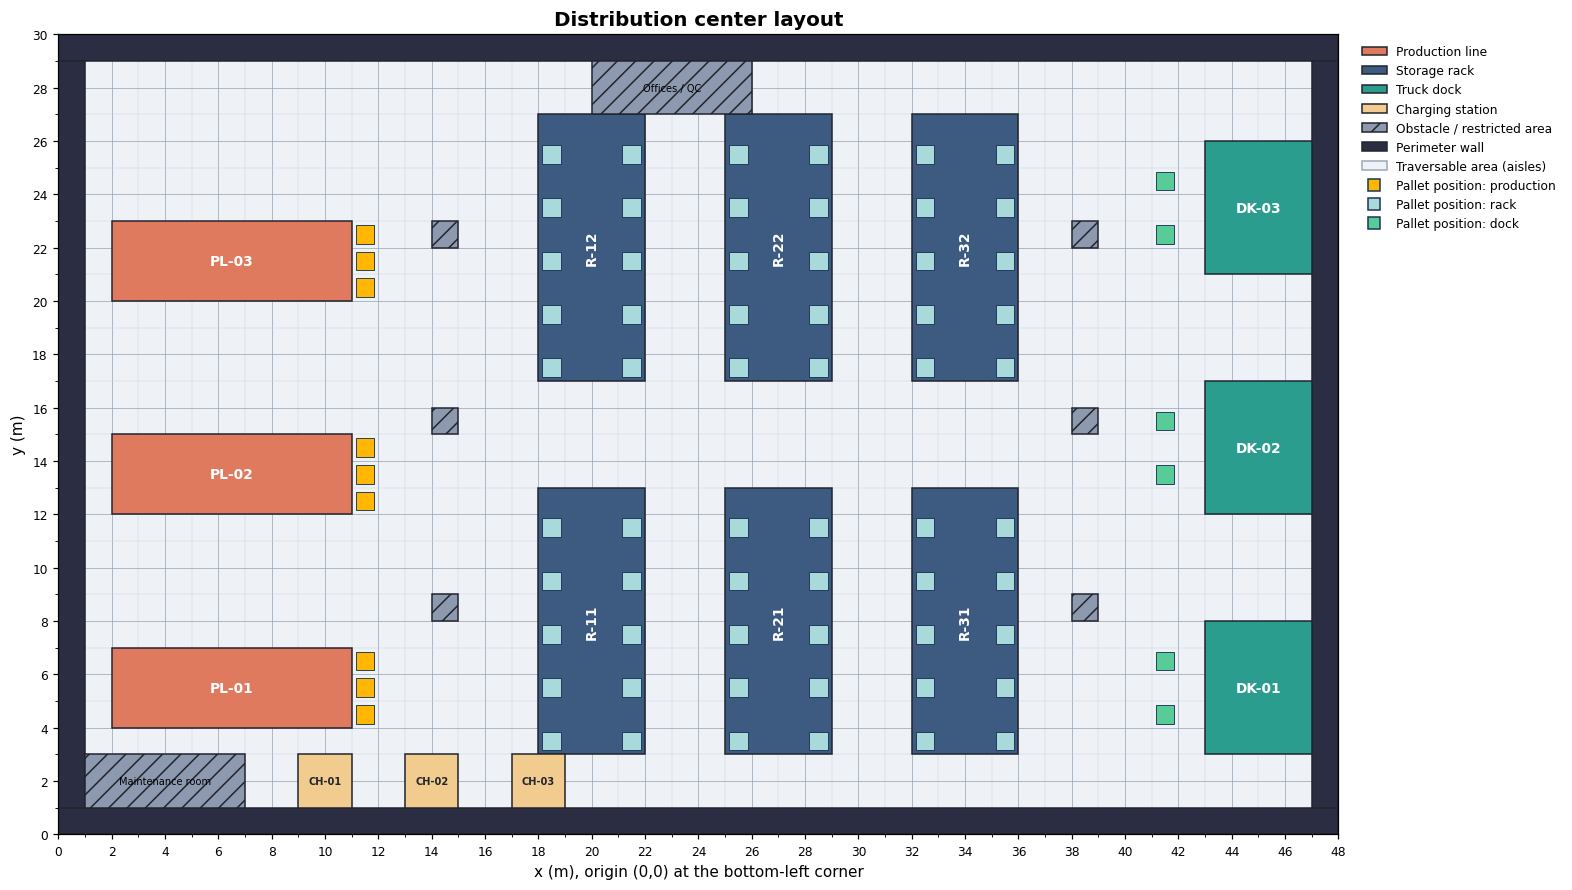

In [ ]:
COLORS = {"production": "#e07a5f", "rack": "#3d5a80", "dock": "#2a9d8f",
          "charger": "#f2cc8f", "obstacle": "#8d99ae", "wall": "#2b2d42"}
NAMES = {"production": "Production line", "rack": "Storage rack", "dock": "Truck dock",
         "charger": "Charging station", "obstacle": "Obstacle / restricted area",
         "wall": "Perimeter wall"}
PALLET_COLORS = {"production": "#ffb703", "rack": "#a8dadc", "dock": "#57cc99"}
FREE_COLOR = "#eef2f7"

FLOWS = {"Production line -> Rack / Truck dock": "#d00000",
         "Rack -> Truck dock": "#3a0ca3",
         "Truck dock -> Rack": "#008000"}


def plot(elements, pallets, grid, P, flows=None, title="Distribution center", path=None):
    fig, ax = plt.subplots(figsize=(15, 8.2))
    dim = .35 if flows else 1.0

    ax.imshow(np.where(grid == FREE, 0, np.nan), cmap=ListedColormap([FREE_COLOR]),
              extent=(0, P["width"], 0, P["height"]), origin="lower", zorder=0)

    for e in elements:
        ax.add_patch(Rectangle((e["x"], e["y"]), e["w"], e["h"], zorder=2, alpha=dim,
                               facecolor=COLORS[e["kind"]], edgecolor="#22252e", lw=1,
                               hatch="//" if e["kind"] == "obstacle" else None))
        if not flows and e["kind"] in ("production", "rack", "dock", "charger"):
            small = e["kind"] == "charger"
            ax.text(e["x"] + e["w"] / 2, e["y"] + e["h"] / 2, e["id"], zorder=4,
                    ha="center", va="center", fontweight="bold",
                    color="#22252e" if small else "white", fontsize=6.5 if small else 9,
                    rotation=90 if e["kind"] == "rack" else 0)
        if not flows and e["label"]:
            ax.text(e["x"] + e["w"] / 2, e["y"] + e["h"] / 2, e["label"], zorder=4,
                    ha="center", va="center", fontsize=6.5)

    for s in pallets:
        ax.add_patch(Rectangle((s["x"] + .15, s["y"] + .15), .7, .7, zorder=3, alpha=dim,
                               facecolor=PALLET_COLORS[s["group"]], edgecolor="#1d3557", lw=.6))

    handles = []
    if flows:
        pos = {s["id"]: (s["x"] + .5, s["y"] + .5) for s in pallets}
        for a, b, kind, rad in flows:
            ax.add_patch(FancyArrowPatch(pos[a], pos[b], color=FLOWS[kind], zorder=6,
                                         connectionstyle=f"arc3,rad={rad}",
                                         arrowstyle="-|>", mutation_scale=16, lw=2))
        handles = [Line2D([], [], color=v, lw=2.5, label=k) for k, v in FLOWS.items()]

    handles += [Patch(facecolor=COLORS[k], edgecolor="#22252e", label=NAMES[k],
                      hatch="//" if k == "obstacle" else None) for k in NAMES]
    handles.append(Patch(facecolor=FREE_COLOR, edgecolor="#9aa8b8",
                         label="Traversable area (aisles)"))
    handles += [Line2D([], [], marker="s", ls="", markerfacecolor=v, markeredgecolor="#1d3557",
                       markersize=8, label=f"Pallet position: {k}")
                for k, v in PALLET_COLORS.items()]

    ax.set_xlim(0, P["width"]); ax.set_ylim(0, P["height"]); ax.set_aspect("equal")
    ax.set_xticks(range(0, P["width"] + 1, 2)); ax.set_yticks(range(0, P["height"] + 1, 2))
    ax.set_xticks(range(P["width"] + 1), minor=True)
    ax.set_yticks(range(P["height"] + 1), minor=True)
    ax.grid(which="minor", color="#c9d3df", lw=.3, zorder=1)
    ax.grid(which="major", color="#9aa8b8", lw=.5, zorder=1)
    ax.set_xlabel("x (m), origin (0,0) at the bottom-left corner"); ax.set_ylabel("y (m)")
    ax.tick_params(labelsize=8)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8,
              frameon=False)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig


plot(elements, pallets, grid, P, title="Distribution center layout",
     path="logistics_environment.png")
plt.show()

## 5. Logistics flows

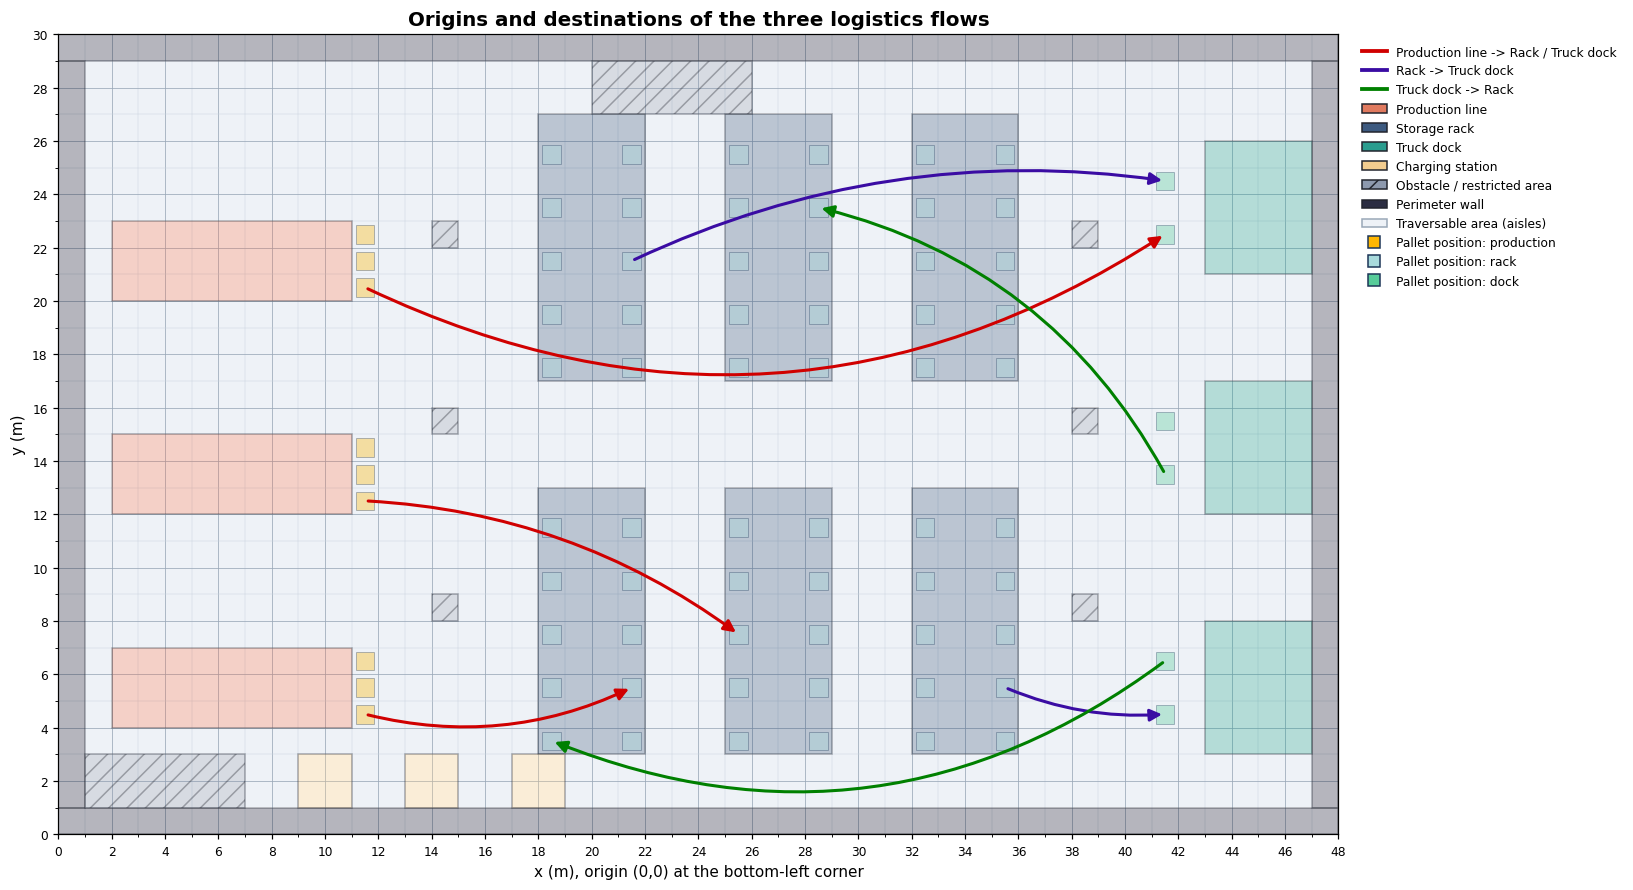

In [ ]:
flows = [
    ("PLB-01-1", "R-11-E2", "Production line -> Rack / Truck dock",  .18),
    ("PLB-02-1", "R-21-W3", "Production line -> Rack / Truck dock", -.15),
    ("PLB-03-1", "DKS-03-1", "Production line -> Rack / Truck dock",  .28),
    ("R-12-E3",  "DKS-03-2", "Rack -> Truck dock",                   -.15),
    ("R-31-E2",  "DKS-01-1", "Rack -> Truck dock",                    .12),
    ("DKS-02-1", "R-22-E4",  "Truck dock -> Rack",                    .22),
    ("DKS-01-2", "R-11-W1",  "Truck dock -> Rack",                   -.28),
]

plot(elements, pallets, grid, P, flows=flows,
     title="Origins and destinations of the three logistics flows",
     path="logistics_flows.png")
plt.show()

## 6. Parametric layout

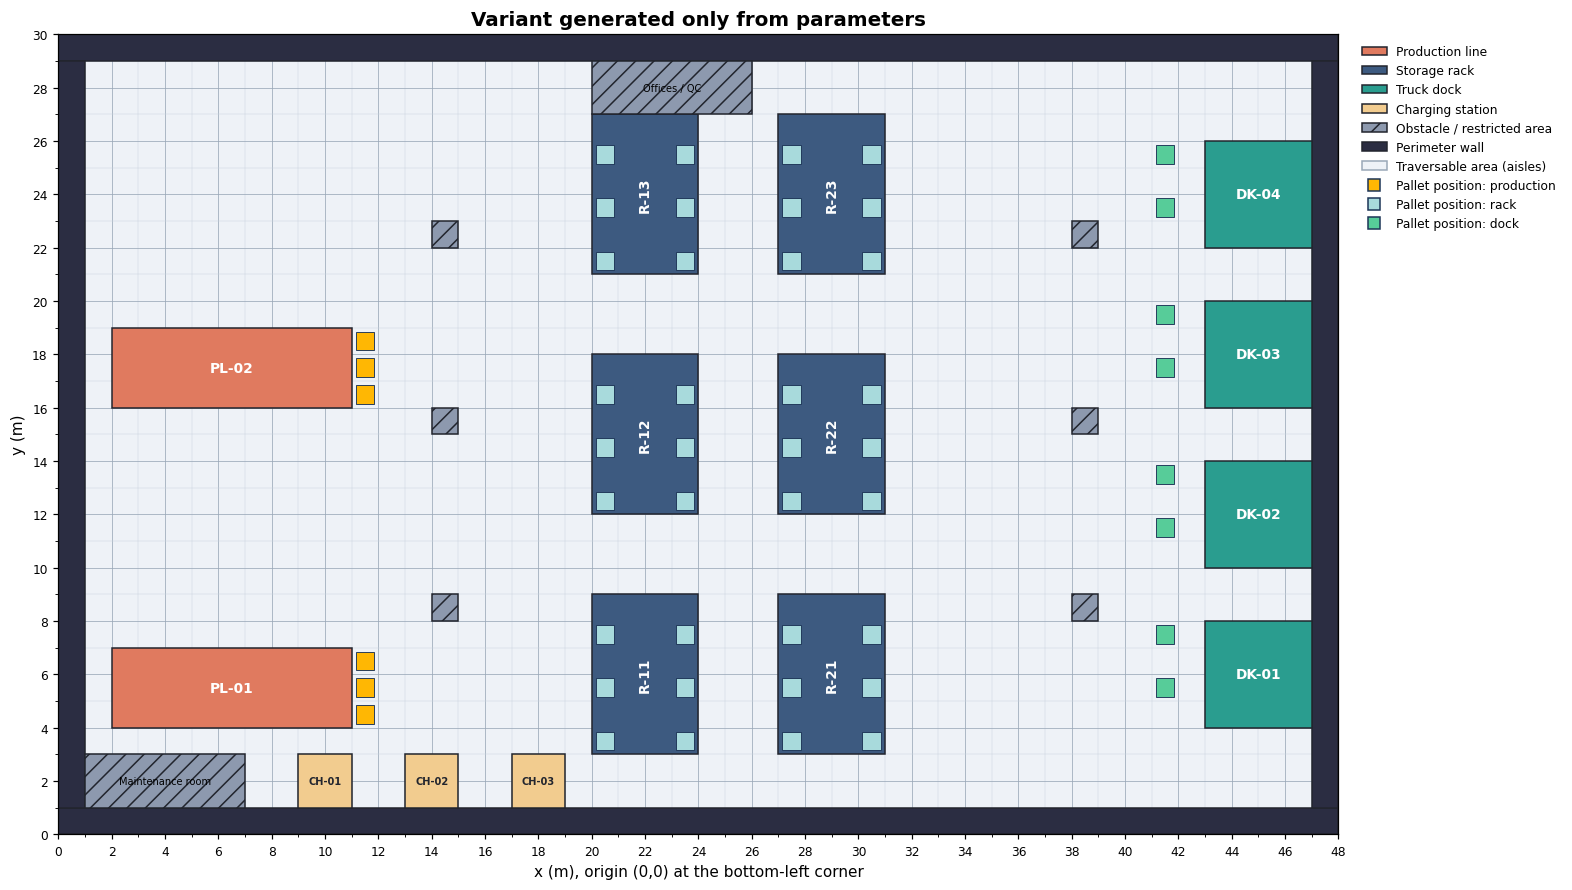

In [ ]:
P_alt = dict(P, rack_x0=20, rack_cols=2, rack_rows=3, rack_h=6, aisle_y=3,
             n_lines=2, line_pitch=12, n_docks=4, dock_h=4, dock_pitch=6, dock_y0=4)

plot(*build(P_alt), P_alt, title="Variant generated only from parameters")
plt.show()

---
# Multi-Agent System



## 7. Fleet constants

In [ ]:
B_MAX, B_THRESHOLD = 100.0, 45.0
C_D, R_C = 0.6, 10.0                 # consumption per cell moved - charge rate per tick
C_IDLE_DRAIN = 0.15                  # standby draw: an idle AGV is not free to park
WD, WB, WL = 2.0, 0.5, 20.0          # Negotiation weights (unchanged, both strategies)
TOW_TIME = 25                        # ticks an AGV is immobilised after running flat

BID_NEAREST, BID_PRIORITY, WAIT, GO_CHARGE = 0, 1, 2, 3
ACTION_NAMES = ["BID_NEAREST", "BID_PRIORITY", "WAIT", "GO_CHARGE"]
N_ACTIONS = 4

# reward weights
R_DONE, C_TIME, C_DIST, P_STRAND, C_IDLE = 100.0, 0.5, 0.3, 150.0, 4.0

## 8. Routing layer - BFS

In this solution:

$$\boxed{\text{BFS} \rightarrow \text{how should the AGV reach the destination?}}$$
$$\boxed{\text{Q-Learning} \rightarrow \text{what should the AGV decide?}}$$

**Why BFS and not A\* or Dijkstra.** The floor is a 4-connected grid with a *uniform* edge cost
(1 m per cell) and only 865 traversable cells. Under uniform cost Dijkstra's priority queue
degenerates into a FIFO queue (it is BFS, with extra overhead) and A\* would only add a
heuristic on a search space small enough that a full expansion takes about 3 ms. BFS is optimal
and complete here, so the extra machinery would buy nothing. This is a deliberate choice, not a
default, and it is why BFS alone is not presented as the intelligent contribution.

BFS is used for three different jobs:

1. **Routing**

  `bfs_path` returns the shortest path, and it accepts a `blocked` set so a route
   can be recomputed around pedestrians, closed aisles or another AGV.
  
2. **Route-length oracle**

A single BFS from a source cell yields the true distance to every
   cell at once. `DistanceOracle` caches those fields, so the whole experiment costs at most 865
   BFS expansions and every later query is an O(1) array lookup.


3. **Feeding the learner**

The energy-reserve feature in the Q-Learning state is computed from
   three cached BFS distances.


In [ ]:
NEI = ((1, 0), (-1, 0), (0, 1), (0, -1))


def nearest_walkable(p, walkable):
    x0, y0 = p
    H, W = walkable.shape
    if 0 <= y0 < H and 0 <= x0 < W and walkable[y0, x0]:
        return p
    dq, seen = deque([p]), {p}
    while dq:
        x, y = dq.popleft()
        for dx, dy in NEI:
            nx, ny = x + dx, y + dy
            if 0 <= nx < W and 0 <= ny < H and (nx, ny) not in seen:
                if walkable[ny, nx]:
                    return (nx, ny)
                seen.add((nx, ny)); dq.append((nx, ny))
    return p


def nearest_free_cell(p, walkable, taken):
    x0, y0 = p
    H, W = walkable.shape
    if 0 <= y0 < H and 0 <= x0 < W and walkable[y0, x0] and (x0, y0) not in taken:
        return (x0, y0)
    dq, seen = deque([p]), {p}
    while dq:
        x, y = dq.popleft()
        for dx, dy in NEI:
            nx, ny = x + dx, y + dy
            if 0 <= nx < W and 0 <= ny < H and (nx, ny) not in seen:
                if walkable[ny, nx] and (nx, ny) not in taken:
                    return (nx, ny)
                seen.add((nx, ny)); dq.append((nx, ny))
    return p


def bfs_path(start, goal, walkable, blocked=frozenset()):
    H, W = walkable.shape
    s = nearest_walkable(start, walkable)
    g = nearest_walkable(goal, walkable)
    if s == g:
        return [s]
    dq, prev = deque([s]), {s: None}
    while dq:
        cur = dq.popleft()
        if cur == g:
            break
        x, y = cur
        for dx, dy in NEI:
            nxt = (x + dx, y + dy)
            nx, ny = nxt
            if (0 <= nx < W and 0 <= ny < H and walkable[ny, nx]
                    and nxt not in prev and nxt not in blocked):
                prev[nxt] = cur; dq.append(nxt)
    if g not in prev:
        return [s]
    path = [g]
    while path[-1] != s:
        path.append(prev[path[-1]])
    path.reverse()
    return path

In [ ]:
class DistanceOracle:
    def __init__(self, walkable):
        self.walkable = walkable
        self._cache = {}
        self.bfs_runs = 0

    def field(self, source):
        s = nearest_walkable(source, self.walkable)
        f = self._cache.get(s)
        if f is None:
            H, W = self.walkable.shape
            f = np.full((H, W), -1, dtype=np.int32)
            f[s[1], s[0]] = 0
            dq = deque([s])
            while dq:
                x, y = dq.popleft()
                d = f[y, x] + 1
                for dx, dy in NEI:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < W and 0 <= ny < H and self.walkable[ny, nx] and f[ny, nx] < 0:
                        f[ny, nx] = d; dq.append((nx, ny))
            self._cache[s] = f
            self.bfs_runs += 1
        return f

    def dist(self, source, target):
        t = nearest_walkable(target, self.walkable)
        d = int(self.field(source)[t[1], t[0]])
        return d if d >= 0 else 10 ** 6

## 9. Scenario

Everything that defines the world: initial AGV positions and batteries, the order stream, the
pedestrian trajectories and the aisle closures, is sampled up front, before the simulation
starts, and never again.

In [ ]:
class Scenario:
    def __init__(self, seed, n_agv=4, horizon=400, mission_rate=0.05,
                 n_pedestrians=3, closure_rate=0.018, n_seed_missions=7):
        self.seed, self.n_agv, self.horizon = seed, n_agv, horizon
        self.mission_rate, self.n_pedestrians = mission_rate, n_pedestrians
        self.closure_rate, self.n_seed_missions = closure_rate, n_seed_missions
        rng = random.Random(seed)
        self.batteries = [rng.choice([55.0, 70.0, 85.0, 100.0]) for _ in range(n_agv)]
        self.mission_rng = random.Random(seed + 3)
        self._pre = None

    def pregenerate(self, walkable, free_cells, pallets, forbidden):
        if self._pre is not None:
            return self._pre
        H, W = walkable.shape
        by_group = defaultdict(list)
        for p in pallets:
            by_group[p["group"]].append(p["id"])

        # mission arrivals
        mrng = self.mission_rng
        def draw(t):
            src, dsts = mrng.choice(FLOW_KINDS)
            o = mrng.choice(by_group[src])
            d = mrng.choice(by_group[mrng.choice(dsts)])
            while d == o:
                d = mrng.choice(by_group[mrng.choice(dsts)])
            return dict(origin=o, destination=d, priority=mrng.choice([1, 1, 2, 3]), t=t)
        schedule = [draw(0) for _ in range(self.n_seed_missions)]
        for t in range(1, self.horizon + 1):
            if mrng.random() < self.mission_rate:
                schedule.append(draw(t))

        # trajectories
        prng = random.Random(self.seed + 4)
        spawnable = [c for c in free_cells if c not in forbidden]
        tracks, used = [], set()
        for _ in range(self.n_pedestrians):
            cell = prng.choice([c for c in spawnable if c not in used])
            used.add(cell)
            track = [cell]
            for _t in range(self.horizon + 1):
                if prng.random() < 0.75:
                    cand = [(cell[0] + dx, cell[1] + dy) for dx, dy in NEI]
                    cand = [c for c in cand if 0 <= c[0] < W and 0 <= c[1] < H
                            and walkable[c[1], c[0]] and c not in forbidden]
                    if cand:
                        cell = cand[prng.randrange(len(cand))]
                track.append(cell)
            tracks.append(track)

        # aisle closures
        erng = random.Random(self.seed + 2)
        closures = []
        for t in range(1, self.horizon + 1):
            if erng.random() < self.closure_rate:
                cx, cy = free_cells[erng.randrange(len(free_cells))]
                horiz = erng.random() < .5
                cells = [(cx + i, cy) if horiz else (cx, cy + i) for i in range(3)]
                cells = [c for c in cells if 0 <= c[0] < W and 0 <= c[1] < H
                         and walkable[c[1], c[0]] and c not in forbidden]
                dur = erng.randint(15, 35)
                if cells:
                    closures.append((t, cells, t + dur))
        self._pre = dict(missions=schedule, tracks=tracks, closures=closures)
        return self._pre


FLOW_KINDS = [("production", ("rack", "dock")), ("rack", ("dock",)), ("dock", ("rack",))]

## 10. Mission manager

The Mission Manager publishes missions, records acceptance, completion and release, and keeps
mission state. It does not choose which AGV executes a mission.

It replays the pre-generated arrival schedule, so mission availability changes over time. A mission is $M_k = (O_k, D_k, P_k, S_k)$ with
origin pallet, destination pallet, priority and a status
`Pending -> Assigned -> Completed` (and `Assigned -> Pending` again if the carrier runs flat).


In [ ]:
class MissionManager:
    def __init__(self, schedule):
        self.schedule = schedule
        self.missions = []
        self._n = 0
        self._i = 0
        self.tick(0)

    def tick(self, t):
        new = []
        while self._i < len(self.schedule) and self.schedule[self._i]["t"] <= t:
            spec = self.schedule[self._i]; self._i += 1
            self._n += 1
            m = dict(id=f"M{self._n:03d}", origin=spec["origin"], destination=spec["destination"],
                     priority=spec["priority"], status="Pending", t_created=t,
                     t_assigned=None, t_completed=None, reassigned=0)
            self.missions.append(m); new.append(m)
        return new

    def pending(self):
        return [m for m in self.missions if m["status"] == "Pending"]

    def record_acceptance(self, m, agv, t):
        m["status"], m["t_assigned"] = "Assigned", t

    def record_completion(self, m, t):
        m["status"], m["t_completed"] = "Completed", t

    def record_release(self, m):
        m["status"], m["t_assigned"] = "Pending", None
        m["reassigned"] += 1


## 11. The AGV

Each AGV is an `Agent` holding
$s_i = (\text{position}_i, \text{battery}_i, \text{status}_i, \text{mission}_i)$ with
{`Available`, `ToPickup`, `Transporting`, `Charging`, `Stranded`}.

The bid is the utility, mechanism unchanged, only $D$ is the true BFS route length
instead of the Manhattan distance:

$$U_{i,k} = -w_d D_{i,k} + w_b B_i - w_l L_i, \qquad w_d = 2.0,\; w_b = 0.5,\; w_l = 20.0$$

and the winner of a mission is

$$AGV^* = \arg\max_i U_{i,k}$$

decided by comparing the agents' own bids. Keeping this identical in both strategies is what
makes the experiment a test of the decision layer and not of the auction.


In [ ]:
class AGV(ap.Agent):

    def setup(self):
        self.status = "Available"
        self.mission = None
        self.path, self.path_idx = [], 0
        self.completed, self.distance = 0, 0
        self.charger = None
        self.battery = B_MAX
        self.wait_streak = 0
        self.tow = 0
        self.replans = 0
        self.idle_ticks, self.active_ticks, self.charge_ticks, self.wait_ticks = 0, 0, 0, 0
        self.charge_events, self.strand_events = 0, 0
        self.energy_used = 0.0
        self.pending_decision = None # (state, action, t0, dist0, done0, strand0)

    @property
    def label(self):
        return f"AGV-{self.id}"

    def bid(self, route_len):
        return -WD * route_len + WB * self.battery - WL * (self.completed / 10)

    def assign_path(self, goal_xy, walkable, blocked=frozenset()):
        self.path = bfs_path((self.x, self.y), goal_xy, walkable, blocked)
        self.path_idx = 0

    def next_cell(self):
        return self.path[self.path_idx + 1] if self.path_idx < len(self.path) - 1 else (self.x, self.y)

    def at_goal(self):
        return self.path_idx >= len(self.path) - 1

    def goal(self):
        return self.path[-1] if self.path else (self.x, self.y)

---

## 12. Problem identification

**Problem A: AGVs strand themselves.**

The rule only checks the battery when an AGV is
`Available`, and it uses a fixed threshold of 45 %. An AGV that accepts a mission at 46 % and
then has to drive pickup -> drop-off -> charger simply does not make it. Measured:
**3.55 run-flat events per 400-tick shift**, each immobilising an AGV for 25 ticks and pushing
its mission back into the queue.

**Problem B: the charging policy is all or nothing and badly timed.**

An AGV charges only when
it drops below the threshold, and then always to 100 %, occupying one of only 3 chargers for a
long block. It never tops up opportunistically while idle.

**Problem C: mission selection ignores whether the mission is even reachable on the remaining
charge.**

The bid mixes distance, battery and workload with hand-picked weights
($w_d, w_b, w_l$ chosen by hand). Nothing in it asks the
 question, after this mission, can I still reach a charger?

All three are the same underlying issue, a decision whose cost is paid much later. Accepting
a far mission now strands the AGV in forty ticks; postponing a top-up now costs a 25-tick tow
later. And the AGV cannot compute that consequence in closed form, because it depends on what
the other three AGVs and the pedestrians do.



## 13. Why Q-Learning

A decision with delayed consequences, taken in a state the agent can observe, in an environment
whose transition probabilities $P(s'|s,a)$ are unknown because they depend on three other
independent agents and on stochastic pedestrians, is by definition a Markov Decision Process
that cannot be solved analytically. Value Iteration would need $P$, we do not have it. That is
exactly the situation model-free reinforcement learning exists for, and Q-Learning is its
simplest form:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\Big[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\Big]$$

### State

Local observation, discretised into 288 states:

$$s_i = \big(\underbrace{b_i}_{4},\; \underbrace{d_i}_{4},\; \underbrace{n}_{3},\; \underbrace{\rho_i}_{3},\; \underbrace{k_i}_{2}\big)$$

| symbol | meaning | buckets |
|---|---|---|
| $b_i$ | own battery | `<25`, `25-50`, `50-75`, `>=75` |
| $d_i$ | BFS route length to the closest pending mission | `<=12`, `<=28`, `>28`, none pending |
| $n$ | pending-mission backlog | `0`, `1-2`, `>=3` |
| $\rho_i$ | energy reserve after the full round trip | `<0`, `0-15`, `>15` |
| $k_i$ | parked on a charger? | no / yes |

$\rho_i$ is where BFS and Q-Learning meet. It is the charge left over *after* the complete
journey, using three cached BFS distances:

$$\rho_i = B_i - c_d\Big[\underbrace{D(p_i, O_k)}_{\text{go to pickup}} + \underbrace{D(O_k, D_k)}_{\text{carry the load}} + \underbrace{\min_{c \in \mathcal{C}} D(D_k, c)}_{\text{reach a charger}}\Big]$$

$\rho_i < 0$ means taking this mission strands me. A hand-written rule could encode that
threshold, but not how to trade it off against backlog, distance and charger contention which
is what has to be learned.

### Actions

$$\mathcal{A} = \{\texttt{BID\_NEAREST},\; \texttt{BID\_PRIORITY},\; \texttt{WAIT},\; \texttt{GO\_CHARGE}\}$$

* `BID_NEAREST` - bid on the pending mission with the shortest BFS route from here;
* `BID_PRIORITY` - bid on the highest-priority pending mission, oldest first;
* `WAIT` - stay available, at a charger this means keep charging, so leaving the charger
  early is simply choosing to bid instead
* `GO_CHARGE` - route to a charger.

`WAIT` is deliberately illegal for an available AGV while work is pending. An unconditional
`WAIT` is an absorbing action: it costs almost nothing and changes nothing, so the policy can
dodge every risk by never committing.


### Reward

Because an action lasts a variable number of ticks (a `WAIT` lasts 1, a mission lasts ~60), this
is a semi-MDP, the decision taken at $t_0$ is only evaluated when the AGV returns to a
decision point at $t_1$, and it is charged with everything that happened in between.

$$r = R_{done}\,\Delta_{completed} \;-\; c_t \Delta t \;-\; c_d \Delta_{cells} \;-\; P_{strand}\,\Delta_{flat} \;-\; c_{idle}\,\Delta t \cdot \mathbb{1}[a = \texttt{WAIT} \wedge n > 0]$$

with $R_{done}=100$, $c_t=0.5$, $c_d=0.3$, $P_{strand}=150$, $c_{idle}=4$, and the update

$$Q(s_0,a_0) \leftarrow Q(s_0,a_0) + \alpha\Big[r + \gamma^{\Delta t}\max_{a' \in \mathcal{A}(s_1)} Q(s_1,a') - Q(s_0,a_0)\Big]$$

$\gamma^{\Delta t}$ is the standard semi-MDP discount. **$\gamma = 0.999$ per tick**, not the usual
0.99, and that choice is load-bearing: at $\gamma = 0.99$ a 60-tick mission has its continuation
value multiplied by $0.99^{60} \approx 0.55$, while a 1-tick `WAIT` keeps 0.99 of it. Discounting
then rewards not committing, and the learned policy idles. At $\gamma = 0.999$ the factor is
$0.999^{60} \approx 0.94$ and long actions are no longer structurally penalised.

The maximum is taken only over legal actions in $s_1$.

### Independent Q-Learning

Each AGV owns a separate $Q$-table and updates it only from its own experience: no shared
parameters, no shared memory, no central critic. The agents influence each other only through
the environment and the auction, which is the honest multi-agent setting. The cost is non-stationarity, while AGV-1 learns, AGV-2's behaviour keeps
changing underneath it, which is why the learning curve is noisier than a single-agent one.


## 13.1 The two proposals, side by side

The experiment of this notebook compares two complete strategies. Because the two are easy to
blur together, the difference is stated here explicitly, before any result is reported, and it is
split into the two questions that are usually confused with each other: **what rule takes the
decision**, and **where the decision is taken**.

### Proposal 1, the baseline: a fixed threshold reactive rule

Carried over unchanged from the M3 implementation. Every AGV at a decision point applies the same
hand written rule, in this order:

1. if it is parked at a charger, keep charging until 100 %;
2. otherwise, if battery $\leq 45\%$, go to a charger;
3. otherwise, if there is work pending, bid on **every** pending mission;
4. otherwise, wait.

The rule is memoryless. It reacts to the battery value at the instant it is read, it never asks
what the battery will be once the mission is over, and it applies the same three bid weights
$(w_d, w_b, w_l)$ whether the queue holds one order or nine.

### Proposal 2, the M4 proposal: a learned, state aware policy

The same AGV replaces steps 1 to 4 with

$$a^{\star} = \arg\max_{a \in \mathcal{A}(s_i)} Q_i(s_i, a), \qquad
\mathcal{A} = \{\texttt{BID\_NEAREST},\ \texttt{BID\_PRIORITY},\ \texttt{WAIT},\ \texttt{GO\_CHARGE}\}$$

where the state $s_i = (b_i, d_i, n, \rho_i, k_i)$ carries the energy reserve $\rho_i$, the charge
that would be left **after** pickup, drop off and reaching the nearest charger. The four
$Q_i$ tables are learned by independent Q-Learning, one per AGV, from 1000 training shifts on
seeds disjoint from the evaluation seeds.

### The difference, line by line

| | **Proposal 1: baseline (M3)** | **Proposal 2: proposed (M4)** |
|---|---|---|
| Decision rule | fixed `if` cascade, written by hand | $\arg\max_a Q_i(s_i,a)$, learned from experience |
| Information used to decide | current battery only | battery, BFS distance to nearest mission, backlog size, energy reserve after the round trip, parked or not |
| Horizon of the decision | the current tick | discounted future, $\gamma = 0.999$ per tick, semi-MDP |
| How many missions it bids on | all pending missions at once | exactly one, either the nearest or the highest priority |
| When it charges | only after crossing the 45 % threshold | whenever the learned value of `GO_CHARGE` is highest, including opportunistic top ups while the queue is empty |
| When it leaves the charger | only at 100 % | as soon as the reserve is comfortable, partial charge allowed |
| Can it decline a mission it cannot finish | no, reachability is never checked | yes, a negative reserve pushes the policy to `GO_CHARGE` |
| What is tuned, and how | three bid weights, chosen by hand | $4 \times 288$ state action values, estimated from 1000 shifts |
| Memory per AGV | none | one $Q$ table, about 107 visited states of 288 |

### What is deliberately identical in both proposals

Layout and occupancy grid, scenario generation (initial positions and batteries, order stream,
pedestrian trajectories, aisle closures), the Mission Manager, the bid utility
$U_{i,k} = -w_d D_{i,k} + w_b B_i - w_l L_i$ **with the same weights**, the auction that awards
each mission to the highest bidder, BFS routing and replanning, the movement arbiter, the battery
physics, the 25 tick tow, the horizon, and the fleet size of 4 AGVs against 3 chargers.

Only the decision layer changes. Every difference reported in section 19 is therefore
attributable to that layer, and to nothing else. Section 17 verifies this numerically.

### Where the decision is taken: centralised control versus independent agents

This is a **second and separate axis**, and it is not what section 19 measures. Both proposals are
decentralised: in both of them the four AGVs decide for themselves and compete in an auction,
and the Mission Manager only publishes missions and reports the $\arg\max$. The baseline is a
decentralised rule based fleet, not a centralised controller, so describing the experiment as
"centralised versus decentralised" would be wrong.

Centralised control is a **third design, considered and rejected before implementation**, for
three reasons:

| | Centralised joint controller (not used) | Independent agents (used in both proposals) |
|---|---|---|
| State space | one joint policy over the fleet, $288^4 \approx 6.88 \times 10^9$ joint states | 288 states per AGV, about 107 of them actually visited |
| Table size | $288^4 \times 4^4 \approx 1.76 \times 10^{12}$ entries, out of reach for a tabular method | $4 \times 288 \times 4 = 4608$ entries |
| Adding a 5th AGV | multiplies the joint space by another factor of 288 | adds one more compact 1152 entry table |
| Failure mode | one controller ingesting the full fleet state every tick is a communication bottleneck and a single point of failure | an AGV that runs flat only removes itself, the fleet continues |
| Cost paid | none of the above | **non-stationarity**: while AGV-1 learns, the other three keep changing underneath it, so the learning curve stays noisy |

Section 19.1 reports the metrics that measure this decentralisation directly, because the fleet
level table of section 19 cannot distinguish a decentralised fleet from a central controller
that happens to produce the same totals.

In [ ]:
BAT_EDGES = (25.0, 50.0, 75.0)
DIST_EDGES = (12, 28)
RESERVE_EDGES = (0.0, 15.0)


def encode_state(agv, model):
    b = int(np.searchsorted(BAT_EDGES, agv.battery, side="right"))
    parked = int(agv.status == "Charging" and (agv.x, agv.y) in model.charger_points)
    pend = model.mm.pending()
    n = len(pend)
    backlog = 0 if n == 0 else (1 if n <= 2 else 2)
    if n == 0:
        return (b, 3, 0, 2, parked)
    m = min(pend, key=lambda mm: model.oracle.dist((agv.x, agv.y), model.anchor(mm["origin"])))
    d = model.oracle.dist((agv.x, agv.y), model.anchor(m["origin"]))
    d_b = int(np.searchsorted(DIST_EDGES, d, side="right"))
    res = int(np.searchsorted(RESERVE_EDGES, model.reserve_after(agv, m), side="right"))
    return (b, d_b, backlog, res, parked)


def legal_actions(agv, model):
    has_work = bool(model.mm.pending())
    parked = agv.status == "Charging" and (agv.x, agv.y) in model.charger_points
    if agv.status == "Available":
        acts = [BID_NEAREST, BID_PRIORITY, GO_CHARGE] if has_work else [WAIT, GO_CHARGE]
    elif parked:
        # WAIT == keep charging; bidding == leave the charger early for a mission
        acts = [BID_NEAREST, BID_PRIORITY, WAIT] if has_work else [WAIT]
    else:
        return []
    return acts


def legal_from_state(s):
    backlog, parked = s[2], s[4]
    if parked:
        return [BID_NEAREST, BID_PRIORITY, WAIT] if backlog > 0 else [WAIT]
    return [BID_NEAREST, BID_PRIORITY, GO_CHARGE] if backlog > 0 else [WAIT, GO_CHARGE]


class QTable:
    def __init__(self):
        self.q = defaultdict(lambda: np.zeros(N_ACTIONS))
        self.visits = defaultdict(int)

    def best(self, s, acts):
        v = self.q[s]
        return max(acts, key=lambda a: v[a])

    def value(self, s, acts):
        return max(self.q[s][a] for a in acts) if acts else 0.0

    def update(self, s, a, target, alpha):
        self.q[s][a] += alpha * (target - self.q[s][a])
        self.visits[s] += 1

## 14. Model

**Communication.** Once per tick the Mission Manager broadcasts every pending mission to every
AGV at a decision point: $\text{Message}_k = (\text{MissionID}, O_k, D_k, P_k)$. Each AGV replies
with $U_{i,k}$ which encodes its own battery and workload, so bids are also how AGVs tell each
other how loaded they are.

**Negotiation.** Missions are resolved in publication order; the highest bidder that is not
already committed this tick wins. The manager reports the $\arg\max$, it does not compute an
assignment.

**Collaboration.** A mission leaves the pending pool the instant it is
accepted, so no two AGVs execute the same one a busy or charging AGV is not at a decision point
and therefore never competes for work it cannot do and a mission whose carrier runs flat is
released back to the pool, where another AGV picks it up.

**Physical arbitration.** Task allocation is decentralised, but movement cannot be, two
independently computed BFS paths can still cross. `_resolve_movement` is the arbiter, reused
verbatim, every AGV proposes its next cell then head-on swaps are cancelled on both sides and
same-cell claims are resolved in favour of whoever is already parked there, before anyone
actually moves. An AGV blocked for +2 ticks replans around the obstruction.

**Dynamic events** Pedestrians walking the aisles (an AGV may
not enter a pedestrian's cell or the cell it is about to step into), aisles temporarily closed
for 15-35 ticks, and a continuously changing set of available missions. Low battery is not
injected as an external event, it emerges from movement as the brief requires.


In [ ]:
class DistributionCenter(ap.Model):

    def setup(self):
        sc, pl = self.p.scenario, self.p.pallets
        self.sc, self.strategy = sc, self.p.strategy
        self.walkable = self.p.walkable
        self.oracle = self.p.oracle
        self.qtables = self.p.get("qtables", None)
        self.alpha = self.p.get("alpha", 0.0)
        self.gamma = self.p.get("gamma", 0.99)
        self.epsilon = self.p.get("epsilon", 0.0)
        self.learning = self.p.get("learning", False)
        self.policy_rng = random.Random(self.p.get("policy_seed", 0))
        self.keep_history = self.p.get("keep_history", False)
        self.verbose = self.p.get("verbose", False)

        self.pallet_by_id = {p["id"]: dict(p, status="stored") for p in pl}
        self._anchor = {}

        chargers = [e for e in self.p.elements if e["kind"] == "charger"]
        self.charger_points = [nearest_walkable((c["x"], c["y"]), self.walkable) for c in chargers]

        spawns, taken = [], set()
        for i in range(sc.n_agv):
            cell = nearest_free_cell(self.charger_points[i % len(self.charger_points)],
                                     self.walkable, taken)
            spawns.append(cell); taken.add(cell)

        H, W = self.walkable.shape
        self.free_cells = [(x, y) for y in range(H) for x in range(W) if self.walkable[y, x]]
        pre = sc.pregenerate(self.walkable, self.free_cells, pl,
                             forbidden=set(spawns) | set(self.charger_points))
        self.mm = MissionManager(pre["missions"])
        self.ped_tracks = pre["tracks"]
        self.closure_schedule = pre["closures"]

        self.agvs = ap.AgentList(self, sc.n_agv, AGV)
        for agv, (x, y), b in zip(self.agvs, spawns, sc.batteries):
            agv.x, agv.y, agv.battery = x, y, b

        self.pedestrians = [list(tr[0]) for tr in self.ped_tracks]
        self.closures = []
        self.dyn_blocked = set()

        self.log, self.history = [], []
        self.n_bids, self.n_messages, self.n_replans = 0, 0, 0
        self.n_ped_deflections = 0
        self.n_contested = 0
        self.ped_cells_walked = 0
        self._refresh_dynamic()
        if self.keep_history:
            self._snapshot()






    def anchor(self, pallet_id):
        a = self._anchor.get(pallet_id)
        if a is None:
            p = self.pallet_by_id[pallet_id]
            a = nearest_walkable((p["x"], p["y"]), self.walkable)
            self._anchor[pallet_id] = a
        return a

    def reserve_after(self, agv, m):
        o, d = self.anchor(m["origin"]), self.anchor(m["destination"])
        leg = (self.oracle.dist((agv.x, agv.y), o) + self.oracle.dist(o, d)
               + min(self.oracle.dist(d, c) for c in self.charger_points))
        return agv.battery - C_D * leg

    def busy_chargers(self):
        return {a.charger for a in self.agvs if a.status == "Charging" and a.charger}

    def agv_cells(self, exclude=None):
        return {(a.x, a.y) for a in self.agvs if a is not exclude}

    def _refresh_dynamic(self, t=None):
        t = self.t if t is None else t
        blocked = set()
        for ped, track in zip(self.pedestrians, self.ped_tracks):
            blocked.add(tuple(ped))
            blocked.add(tuple(track[min(t + 1, len(track) - 1)]))
        for cells, _exp in self.closures:
            blocked |= set(cells)
        self.dyn_blocked = blocked

    def _step_events(self, t):
        cells = self.agv_cells()
        for i, track in enumerate(self.ped_tracks):
            nxt = track[min(t, len(track) - 1)]
            if nxt in cells:
                self.n_ped_deflections += 1
                continue
            if tuple(self.pedestrians[i]) != nxt:
                self.ped_cells_walked += 1
            self.pedestrians[i] = list(nxt)
        for start, cells, end in self.closure_schedule:
            if start == t:
                self.closures.append([cells, end])
                self.log.append(f"t{t:03d} | EVENT aisle closed around {cells[0]} until t{end}")
        self.closures = [c for c in self.closures if c[1] > t]
        self._refresh_dynamic()


    def _close_decision(self, agv, t):
        if agv.pending_decision is None:
            return
        s0, a0, t0, d0, done0, str0 = agv.pending_decision
        agv.pending_decision = None
        if not self.learning:
            return
        dt = max(1, t - t0)
        R = (R_DONE * (agv.completed - done0)
             - C_TIME * dt
             - C_DIST * (agv.distance - d0)
             - P_STRAND * (agv.strand_events - str0))
        if a0 == WAIT and s0[2] > 0:
            R -= C_IDLE * dt
        s1 = encode_state(agv, self)
        acts1 = legal_actions(agv, self)
        target = R + (self.gamma ** dt) * self.qtables[agv.id].value(s1, acts1)
        self.qtables[agv.id].update(s0, a0, target, self.alpha)

    def _choose(self, agv, t):
        acts = legal_actions(agv, self)
        if not acts:
            return None
        if self.strategy == "baseline":
            if agv.status == "Charging":
                return WAIT
            if agv.battery <= B_THRESHOLD:
                return GO_CHARGE
            return BID_NEAREST if self.mm.pending() else WAIT
        s = encode_state(agv, self)
        if self.policy_rng.random() < self.epsilon:
            a = self.policy_rng.choice(acts)
        else:
            a = self.qtables[agv.id].best(s, acts)
        agv.pending_decision = (s, a, t, agv.distance, agv.completed, agv.strand_events)
        return a

    def _decide_and_negotiate(self, t):
        pending = self.mm.pending()
        offers = defaultdict(list)
        going_to_charge = []
        for agv in self.agvs:
            if not legal_actions(agv, self):
                continue
            self._close_decision(agv, t)
            a = self._choose(agv, t)
            if a is None:
                continue
            if a == GO_CHARGE:
                going_to_charge.append(agv)
            elif a in (BID_NEAREST, BID_PRIORITY) and pending:
                self.n_messages += len(pending)
                if self.strategy == "baseline":
                    targets = pending
                elif a == BID_NEAREST:
                    targets = [min(pending, key=lambda m: self.oracle.dist(
                        (agv.x, agv.y), self.anchor(m["origin"])))]
                else:
                    targets = [max(pending, key=lambda m: (m["priority"], -m["t_created"]))]
                for m in targets:
                    D = self.oracle.dist((agv.x, agv.y), self.anchor(m["origin"]))
                    u = agv.bid(D)
                    offers[m["id"]].append((agv, u))
                    self.n_bids += 1
                    if self.verbose:
                        self.log.append(
                            f"t{t:03d} |   BID  {agv.label} -> {m['id']}  U={u:8.1f}  "
                            f"(BFS route {D:3d} cells, battery {agv.battery:5.1f}%, "
                            f"{agv.completed} done)")
            elif a == WAIT and agv.status == "Available":
                agv.wait_ticks += 1

        # negotiation
        busy = set()
        for m in pending:
            bidders = [(a, u) for a, u in offers.get(m["id"], []) if a.id not in busy]
            if not bidders:
                continue
            winner, u = max(bidders, key=lambda p: p[1])
            busy.add(winner.id)
            if len(bidders) > 1:
                self.n_contested += 1
            self.mm.record_acceptance(m, winner, t)
            winner.status, winner.mission, winner.charger = "ToPickup", m["id"], None
            self.pallet_by_id[m["origin"]]["status"] = "reserved"
            winner.assign_path(self.anchor(m["origin"]), self.walkable, self.dyn_blocked)
            self._settle_arrivals(winner, t)
            if self.verbose:
                self.log.append(f"t{t:03d} | WIN  {winner.label} takes {m['id']} with U={u:.1f} "
                                f"(beat {len(bidders)-1} rival bid(s)) -> ToPickup")

        occupied = self.busy_chargers()
        for agv in going_to_charge:
            target = min(self.charger_points,
                         key=lambda c: (c in occupied, self.oracle.dist((agv.x, agv.y), c)))
            occupied.add(target)
            agv.status, agv.charger = "Charging", target
            agv.assign_path(target, self.walkable, self.dyn_blocked)
            if self.verbose:
                self.log.append(f"t{t:03d} | {agv.label} heads to charger {target} "
                                f"(battery {agv.battery:.0f}%)")




    def step(self):
        t = self.t
        self.mm.tick(t)
        self._step_events(t)
        self._decide_and_negotiate(t)
        self._resolve_movement(t)
        self._service(t)
        for a in self.agvs:
            if a.status in ("ToPickup", "Transporting"):
                a.active_ticks += 1
            elif a.status == "Charging":
                a.charge_ticks += 1
            elif a.status == "Available":
                a.idle_ticks += 1
                a.battery = max(0.0, a.battery - C_IDLE_DRAIN)
                a.energy_used += C_IDLE_DRAIN
        if self.keep_history:
            self._snapshot()
        if t >= self.sc.horizon:
            self.stop()

    def _settle_arrivals(self, agv, t, guard=4):
        while guard > 0 and agv.status in ("ToPickup", "Transporting") and agv.at_goal():
            self._on_arrival(agv, t)
            guard -= 1

    def _resolve_movement(self, t):
        walkable, dyn = self.walkable, self.dyn_blocked
        moving = [a for a in self.agvs
                  if a.status in ("ToPickup", "Transporting", "Charging")
                  and not (a.status == "Charging" and (a.x, a.y) in self.charger_points)]

        for a in moving:
            if a.next_cell() in dyn:
                new = bfs_path((a.x, a.y), a.goal(), walkable, dyn)
                a.replans += 1
                self.n_replans += 1
                if len(new) > 1:
                    a.path, a.path_idx = new, 0

        current = {a: (a.x, a.y) for a in self.agvs}
        intended = dict(current)
        for a in moving:
            nc = a.next_cell()
            intended[a] = current[a] if nc in dyn else nc

        changed = True
        while changed:
            changed = False
            for a in moving:
                for b in moving:
                    if (a is not b and intended[a] == current[b] and intended[b] == current[a]
                            and intended[a] != current[a]):
                        intended[a], intended[b] = current[a], current[b]
                        changed = True
            by_target = defaultdict(list)
            for a in self.agvs:
                by_target[intended[a]].append(a)
            for claimants in by_target.values():
                if len(claimants) <= 1:
                    continue
                holder = next((g for g in claimants if intended[g] == current[g]), None)
                movers = [g for g in claimants if g is not holder]
                if holder is None:
                    movers.sort(key=lambda g: g.id)
                    holder, movers = movers[0], movers[1:]
                for loser in movers:
                    if intended[loser] != current[loser]:
                        intended[loser] = current[loser]
                        changed = True

        for agv in moving:
            if intended[agv] == current[agv]:
                agv.wait_streak += 1
                if agv.wait_streak >= 2:
                    blocked = set(dyn) | (self.agv_cells(agv) - {agv.goal()})
                    detour = bfs_path((agv.x, agv.y), agv.goal(), walkable, blocked)
                    agv.replans += 1
                    self.n_replans += 1
                    if len(detour) > 1:
                        agv.path, agv.path_idx, agv.wait_streak = detour, 0, 0
                continue
            agv.wait_streak = 0
            agv.path_idx += 1
            agv.x, agv.y = intended[agv]
            agv.battery = max(0.0, agv.battery - C_D)
            agv.energy_used += C_D
            agv.distance += 1
            if agv.battery <= 0.0:
                self._strand(agv, t)
                continue
            if agv.at_goal():
                self._on_arrival(agv, t)
                self._settle_arrivals(agv, t)

    def _strand(self, agv, t):
        agv.strand_events += 1
        agv.status, agv.tow, agv.charger = "Stranded", TOW_TIME, None
        agv.path, agv.path_idx = [(agv.x, agv.y)], 0
        if agv.mission:
            m = next(mm for mm in self.mm.missions if mm["id"] == agv.mission)
            self.mm.record_release(m)
            self.pallet_by_id[m["origin"]]["status"] = "waiting for pickup"
            agv.mission = None
        self.log.append(f"t{t:03d} | {agv.label} RAN FLAT at ({agv.x},{agv.y}) "
                        f"-> immobilised for {TOW_TIME} ticks, mission returned to the pool")

    def _on_arrival(self, agv, t):
        if agv.status == "ToPickup":
            m = next(mm for mm in self.mm.missions if mm["id"] == agv.mission)
            self.pallet_by_id[m["origin"]]["status"] = "being transported"
            agv.status = "Transporting"
            agv.assign_path(self.anchor(m["destination"]), self.walkable, self.dyn_blocked)
        elif agv.status == "Transporting":
            m = next(mm for mm in self.mm.missions if mm["id"] == agv.mission)
            self.mm.record_completion(m, t)
            self.pallet_by_id[m["origin"]]["status"] = "delivered"
            agv.completed += 1
            agv.mission, agv.status = None, "Available"
            if self.verbose:
                self.log.append(f"t{t:03d} | {agv.label} completed {m['id']}")

    def _service(self, t):
        for agv in self.agvs:
            if agv.status == "Stranded":
                agv.tow -= 1
                if agv.tow <= 0:
                    agv.status, agv.battery = "Available", 30.0
                    self.log.append(f"t{t:03d} | {agv.label} recovered by maintenance (30%)")
            elif agv.status == "Charging" and (agv.x, agv.y) in self.charger_points:
                if agv.battery < B_MAX:
                    if agv.battery + R_C >= B_MAX:
                        agv.charge_events += 1
                    agv.battery = min(B_MAX, agv.battery + R_C)
                if agv.battery >= B_MAX:
                    agv.status, agv.charger = "Available", None

    def _snapshot(self):
        self.history.append(dict(
            t=self.t,
            agvs=[dict(id=a.label, x=a.x, y=a.y, battery=a.battery, status=a.status,
                       mission=a.mission, completed=a.completed) for a in self.agvs],
            peds=[tuple(p) for p in self.pedestrians],
            closed=sorted(c for cells, _ in self.closures for c in cells),
            pending=len(self.mm.pending())))

## 15. Metrics

Mandatory:

$$\text{Throughput} = \frac{N_{completed}}{T_{simulation}}, \qquad
\overline{T}_{mission} = \frac{1}{N}\sum_{k=1}^{N}\big(T_k^{complete}-T_k^{start}\big), \qquad
\text{Utilization}_i = \frac{T_i^{active}}{T_{simulation}}\times 100\%$$

Two mission-time metrics are reported, because they answer different questions, **cycle time**
runs from the moment the order is published to delivery (it includes queueing, so it is what a
customer would feel), and **execution time** runs from acceptance to delivery.
A strategy can improve one and not the other.

Supporting metrics chosen because they are what this proposal actually claims to change:
distance and energy per mission, idle and charging share, **run-flat events**, full-charge
events, missions still pending at the end, and BFS replanning events.

**Metrics of the decentralised strategy** (section 19.1). The three mandatory metrics are fleet
aggregates: a single central controller producing the same totals would be indistinguishable from
this fleet in them. Because the strategy proposed here is decentralised, a third family is
reported that measures the decentralisation itself:

| Family | Metric | What it answers |
|---|---|---|
| Load balance | per AGV missions, utilisation, distance, run flats; $CV = \sigma/\mu$ and Gini of the missions vector; share carried by the busiest and quietest AGV | does work spread evenly when nothing balances it? |
| Cost of the market layer | bids per tick, bids per accepted mission, contested share of auctions, missions released back to the pool | what does coordinating through an auction cost in messages? |
| Policy heterogeneity | states visited per AGV, states visited by all four, share of those where the greedy action differs, pairwise agreement matrix | did the four independent learners actually produce four different policies? |
| Scalability | table entries decentralised versus a single joint policy, and the cost of adding one AGV | was independent learning necessary, or only convenient? |


In [ ]:
def collect_metrics(model):
    T = float(model.t)
    ms = model.mm.missions
    done = [m for m in ms if m["status"] == "Completed"]
    cycle = [m["t_completed"] - m["t_created"] for m in done]
    exec_t = [m["t_completed"] - m["t_assigned"] for m in done if m["t_assigned"] is not None]
    util = [a.active_ticks / T * 100 for a in model.agvs]
    dist = sum(a.distance for a in model.agvs)
    energy = sum(a.energy_used for a in model.agvs)
    return {
        "missions_completed": len(done),
        "missions_published": len(ms),
        "throughput_per_100t": len(done) / T * 100,
        "avg_cycle_time": float(np.mean(cycle)) if cycle else float("nan"),
        "avg_exec_time": float(np.mean(exec_t)) if exec_t else float("nan"),
        "avg_utilization_pct": float(np.mean(util)),
        "pending_at_end": len(model.mm.pending()),
        "total_distance": dist,
        "distance_per_mission": dist / len(done) if done else float("nan"),
        "idle_pct": float(np.mean([a.idle_ticks / T * 100 for a in model.agvs])),
        "charging_pct": float(np.mean([a.charge_ticks / T * 100 for a in model.agvs])),
        "charge_events": sum(a.charge_events for a in model.agvs),
        "strand_events": sum(a.strand_events for a in model.agvs),
        "reassigned_missions": sum(m["reassigned"] for m in ms),
        "replans": model.n_replans,
        "bids": model.n_bids,
        "energy_per_mission": energy / len(done) if done else float("nan"),
    }


def run_episode(strategy, scenario, env, qtables=None, learning=False,
                alpha=0.0, gamma=0.99, epsilon=0.0, policy_seed=0,
                keep_history=False, verbose=False):
    elements, pallets, walkable, oracle = env
    model = DistributionCenter(dict(
        scenario=scenario, strategy=strategy, elements=elements, pallets=pallets,
        walkable=walkable, oracle=oracle, qtables=qtables, learning=learning,
        alpha=alpha, gamma=gamma, epsilon=epsilon, policy_seed=policy_seed,
        keep_history=keep_history, verbose=verbose))
    model.run(steps=scenario.horizon, display=False)
    return model

### Build the environment objects

In [ ]:
walkable = grid == FREE
oracle = DistanceOracle(walkable)
ENV = (elements, pallets, walkable, oracle)

print(f"Traversable cells        : {walkable.sum()}")
print(f"Pallet positions         : {len(pallets)}")
print(f"Charging station anchors : "
      f"{[nearest_walkable((e['x'], e['y']), walkable) for e in elements if e['kind'] == 'charger']}")

Traversable cells        : 865
Pallet positions         : 75
Charging station anchors : [(8, 1), (12, 1), (16, 1)]


In [ ]:
STATUS_COLOR = {"Available": "#8d99ae", "ToPickup": "#e63946",
                "Transporting": "#2a9d8f", "Charging": "#f4a261", "Stranded": "#000000"}
AGV_COLORS = ["#e63946", "#2a9d8f", "#f4a261", "#6a4c93", "#118ab2", "#d62828"]


def make_animation(model, plot_fn, elements, pallets, grid, P, step=5, dpi=56, title=None):
    history = model.history
    frames = history[::step]
    fig = plot_fn(elements, pallets, grid, P,
                  title=title or "AGV fleet - M4 intelligent strategy")
    fig.set_dpi(dpi)
    fig.set_size_inches(11.5, 6.3)
    ax = fig.axes[0]

    ids = [a["id"] for a in frames[0]["agvs"]]
    dots, rings, labels = {}, {}, {}
    for k, i in enumerate(ids):
        rings[i] = ax.plot([], [], marker="o", ms=21, mec="none",
                           mfc=AGV_COLORS[k % len(AGV_COLORS)], alpha=.35, zorder=7)[0]
        dots[i] = ax.plot([], [], marker="o", ms=15, mec="black", mew=1.2,
                          mfc=AGV_COLORS[k % len(AGV_COLORS)], zorder=8)[0]
        labels[i] = ax.text(0, 0, i.split("-")[1], fontsize=7, fontweight="bold",
                            ha="center", va="center", color="white", zorder=9)
    peds = ax.plot([], [], ls="", marker="*", ms=13, mfc="#ffd166",
                   mec="#7f5539", mew=.8, zorder=10)[0]
    closed = ax.plot([], [], ls="", marker="x", ms=8, mfc="none",
                     mec="#d00000", mew=2, zorder=10)[0]
    info = ax.text(1.01, 0.0, "", transform=ax.transAxes, fontsize=7.5,
                   va="bottom", family="monospace")

    def update(fi):
        snap = frames[fi]
        lines = [f"t = {snap['t']:03d}",
                 f"pending missions : {snap['pending']:2d}",
                 f"completed        : {sum(a['completed'] for a in snap['agvs']):2d}",
                 ""]
        for a in snap["agvs"]:
            dots[a["id"]].set_data([a["x"] + .5], [a["y"] + .5])
            dots[a["id"]].set_markeredgecolor(STATUS_COLOR.get(a["status"], "black"))
            rings[a["id"]].set_data([a["x"] + .5], [a["y"] + .5])
            labels[a["id"]].set_position((a["x"] + .5, a["y"] + .5))
            carried = a["mission"] if a["status"] == "Transporting" else "-"
            lines.append(f"{a['id']:6s}{a['status']:<13s}{a['battery']:5.1f}%  "
                         f"{carried or '-':5s} done {a['completed']}")
        if snap["peds"]:
            peds.set_data([p[0] + .5 for p in snap["peds"]], [p[1] + .5 for p in snap["peds"]])
        if snap["closed"]:
            closed.set_data([c[0] + .5 for c in snap["closed"]], [c[1] + .5 for c in snap["closed"]])
        else:
            closed.set_data([], [])
        lines += ["", "* pedestrian   x closed aisle",
                  "ring colour = AGV, outline = status"]
        info.set_text("\n".join(lines))
        return list(dots.values()) + list(rings.values()) + list(labels.values()) + [peds, closed, info]

    anim = FuncAnimation(fig, update, frames=len(frames), interval=130, blit=False)
    plt.close(fig)
    return anim

In [ ]:
def plot_learning_curve(curve, window=25):
    c = lambda k: np.array([r[k] for r in curve], float)
    sm = lambda v: np.convolve(v, np.ones(window) / window, mode="valid")
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
    ax[0].plot(sm(c("throughput")), color="#2a9d8f")
    ax[0].set_title("Throughput (missions / 100 ticks)")
    ax[1].plot(sm(c("strands")), color="#e63946")
    ax[1].set_title("Run-flat events per episode")
    ax[2].plot(c("epsilon"), color="#6a4c93")
    ax[2].set_title(r"Exploration rate $\epsilon$")
    for a in ax:
        a.set_xlabel("training episode"); a.grid(alpha=.3)
    fig.suptitle(f"Independent Q-Learning convergence (moving average, window={window})",
                 fontweight="bold")
    fig.tight_layout()
    return fig


def plot_comparison(base_rows, prop_rows):
    g = lambda rows, k: np.array([r[k] for r in rows], float)
    specs = [("throughput_per_100t", "Throughput\n(missions / 100 ticks)", True),
             ("avg_cycle_time", "Average mission cycle time\n(ticks, order -> delivered)", False),
             ("distance_per_mission", "Distance per mission\n(cells)", False),
             ("strand_events", "Run-flat events\nper episode", False)]
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
    for ax, (key, title, higher_better) in zip(axes, specs):
        b, p = g(base_rows, key), g(prop_rows, key)
        ax.boxplot([b, p], widths=.55, patch_artist=True,
                   boxprops=dict(facecolor="#dfe7ef", edgecolor="#22252e"),
                   medianprops=dict(color="#d00000", lw=2))
        ax.set_xticks([1, 2]); ax.set_xticklabels(["Baseline", "Q-Learning"])
        for i, v in ((1, b), (2, p)):
            ax.plot(np.full(len(v), i) + np.random.uniform(-.07, .07, len(v)), v,
                    "o", ms=3.5, color="#22252e", alpha=.55)
        for x0, x1 in zip(b, p):
            ax.plot([1, 2], [x0, x1], color="#9aa8b8", lw=.6, alpha=.6, zorder=0)
        good = "higher is better" if higher_better else "lower is better"
        ax.set_title(f"{title}\n({good})", fontsize=9)
        ax.grid(alpha=.3, axis="y")
    fig.suptitle("Baseline vs proposed strategy - 20 paired scenarios "
                 "(grey lines join the same seed)", fontweight="bold")
    fig.tight_layout()
    return fig

---
# Experiments

## 16. Evidence for the problem statement

Before proposing anything, the diagnosis of section 12 is measured on the baseline.


In [ ]:
diag = [collect_metrics(run_episode("baseline", Scenario(seed=s, horizon=400), ENV))
        for s in range(20)]
mean = lambda k: float(np.nanmean([d[k] for d in diag]))

print("Baseline over 20 shifts of 400 ticks, 4 AGVs, 3 chargers")
print("-" * 72)
print(f"  A  run-flat events per shift        : {mean('strand_events'):6.2f}"
      f"   ({mean('strand_events') * 25:.0f} ticks of AGV time lost to tows)")
print(f"     missions released and re-queued  : {mean('reassigned_missions'):6.2f}")
print(f"  B  share of time spent charging     : {mean('charging_pct'):6.2f} %")
print(f"     full 0->100 % charge events      : {mean('charge_events'):6.2f}")
print(f"  C  distance driven per mission      : {mean('distance_per_mission'):6.2f} cells")
print(f"     energy drawn per mission         : {mean('energy_per_mission'):6.2f} %-battery")
print("-" * 72)
print(f"     throughput                       : {mean('throughput_per_100t'):6.2f} missions / 100 ticks")
print(f"     mission cycle time (order->done) : {mean('avg_cycle_time'):6.2f} ticks")
print(f"     missions still pending at t=400  : {mean('pending_at_end'):6.2f}")

Baseline (= the M3 decision rule) over 20 shifts of 400 ticks, 4 AGVs, 3 chargers
------------------------------------------------------------------------
  A  run-flat events per shift        :   3.45   (86 ticks of AGV time lost to tows)
     missions released and re-queued  :   0.45
  B  share of time spent charging     :  23.52 %
     full 0->100 % charge events      :   7.35
  C  distance driven per mission      :  85.43 cells
     energy drawn per mission         :  51.60 %-battery
------------------------------------------------------------------------
     throughput                       :   4.04 missions / 100 ticks
     mission cycle time (order->done) : 142.75 ticks
     missions still pending at t=400  :   8.15


## 17. Verifying the fair experimental design

Here it is checked numerically, for each
seed, both strategies are run and the resulting worlds are compared field by field, the order
stream, the pedestrian positions at every tick, the closed cells at every tick and the initial
batteries must be identical.




In [ ]:
qt_probe = {i + 1: QTable() for i in range(4)}
diff_world = stacked = on_ped = in_obstacle = deflections = 0

for seed in range(10):
    runs = {}
    for strat, qt in (("baseline", None), ("qlearn", qt_probe)):
        m = run_episode(strat, Scenario(seed=seed, horizon=400), ENV,
                        qtables=qt, keep_history=True)
        runs[strat] = m
        deflections += m.n_ped_deflections
        for snap in m.history:
            cells = [(a["x"], a["y"]) for a in snap["agvs"]]
            stacked += len(set(cells)) != len(cells)
            on_ped += bool(set(cells) & set(snap["peds"]))
            in_obstacle += any(not walkable[a["y"], a["x"]] for a in snap["agvs"])
    b, p = runs["baseline"], runs["qlearn"]
    sched = lambda m: (
        [(x["t_created"], x["origin"], x["destination"], x["priority"]) for x in m.mm.missions],
        m.ped_tracks, m.closure_schedule, m.sc.batteries)
    diff_world += sched(b) != sched(p)

print("Equivalent conditions (10 seeds x 2 strategies)")
print("  Compared field by field: the order stream, every pedestrian trajectory, every")
print("  closure interval and the initial batteries.")
print(f"  seeds where the two worlds differed .......... {diff_world} / 10   (must be 0)")
print(f"  pedestrian detours around a stalled AGV ...... {deflections}"
      "   (the one reactive interaction, reported not hidden)")
print()
print("Physical invariants, re-checked on every recorded frame")
print(f"  frames with two AGVs on the same cell ........ {stacked}")
print(f"  frames with an AGV on a pedestrian ........... {on_ped}")
print(f"  frames with an AGV inside an obstacle ........ {in_obstacle}")
print()
print(f"Orders published per scenario (identical both ways): {len(b.mm.missions)}")

Equivalent conditions (10 seeds x 2 strategies)
  Compared field by field: the order stream, every pedestrian trajectory, every
  closure interval and the initial batteries.
  seeds where the two worlds differed .......... 0 / 10   (must be 0)
  pedestrian detours around a stalled AGV ...... 6   (the one reactive interaction, reported not hidden)

Physical invariants, re-checked on every recorded frame
  frames with two AGVs on the same cell ........ 0
  frames with an AGV on a pedestrian ........... 0
  frames with an AGV inside an obstacle ........ 0

Orders published per scenario (identical both ways): 24


## 18. Training

Training and evaluation scenarios are disjoint. Training uses seeds `10000 ... 10999`,
evaluation uses seeds `0 ... 19`. The policy is therefore measured on shifts it has never seen,
so the comparison reports generalisation and not memorisation.

Exploration decays geometrically from $\epsilon = 1.0$ to $\epsilon = 0.05$; evaluation is fully
greedy ($\epsilon = 0$).


In [ ]:
RATE = 0.05
HORIZON_TRAIN = 400
HORIZON_EVAL = 400
N_AGV = 4
TRAIN_SEED_BASE = 10_000


def make_qtables(n_agv):
    return {i + 1: QTable() for i in range(n_agv)}


def train(env, episodes=400, alpha=0.15, gamma=0.99, eps_start=1.0, eps_end=0.05,
          horizon=HORIZON_TRAIN, rate=RATE, log_every=50, seed_offset=0):
    qtables = make_qtables(N_AGV)
    decay = (eps_end / eps_start) ** (1.0 / max(1, episodes - 1))
    eps, curve = eps_start, []
    for ep in range(episodes):
        sc = Scenario(seed=TRAIN_SEED_BASE + seed_offset + ep, n_agv=N_AGV,
                        horizon=horizon, mission_rate=rate)
        m = run_episode("qlearn", sc, env, qtables=qtables, learning=True,
                          alpha=alpha, gamma=gamma, epsilon=eps, policy_seed=seed_offset + ep)
        met = collect_metrics(m)
        curve.append(dict(episode=ep, epsilon=eps,
                          completed=met["missions_completed"],
                          throughput=met["throughput_per_100t"],
                          strands=met["strand_events"],
                          util=met["avg_utilization_pct"]))
        if log_every and (ep % log_every == 0 or ep == episodes - 1):
            w = curve[-log_every:]
            print(f"  ep {ep:4d} | eps {eps:.3f} | throughput(last{len(w)}) "
                  f"{np.mean([c['throughput'] for c in w]):5.2f} | strands "
                  f"{np.mean([c['strands'] for c in w]):4.2f}")
        eps *= decay
    return qtables, curve


def evaluate(env, strategy, qtables=None, seeds=range(10),
             horizon=HORIZON_EVAL, rate=RATE):
    rows = []
    for s in seeds:
        sc = Scenario(seed=s, n_agv=N_AGV, horizon=horizon, mission_rate=rate)
        m = run_episode(strategy, sc, env, qtables=qtables, learning=False,
                          alpha=0.0, epsilon=0.0, policy_seed=s)
        r = collect_metrics(m)
        r["seed"] = s
        rows.append(r)
    return rows


def summarise(rows, keys):
    return {k: (float(np.nanmean([r[k] for r in rows])),
                float(np.nanstd([r[k] for r in rows]))) for k in keys}

In [ ]:
EPISODES = 1000
ALPHA, GAMMA = 0.10, 0.999
EPS_START, EPS_END = 1.0, 0.05

t0 = time.time()
qtables, curve = train(ENV, episodes=EPISODES, alpha=ALPHA, gamma=GAMMA,
                       eps_start=EPS_START, eps_end=EPS_END, log_every=200)
print(f"\ntraining time: {time.time() - t0:.0f} s")
print(f"states visited per AGV: {[len(q.q) for q in qtables.values()]} of 288 possible")

  ep    0 | eps 1.000 | throughput(last1)  2.00 | strands 15.00
  ep  200 | eps 0.549 | throughput(last200)  3.53 | strands 11.76
  ep  400 | eps 0.301 | throughput(last200)  3.64 | strands 9.29
  ep  600 | eps 0.165 | throughput(last200)  4.04 | strands 6.22
  ep  800 | eps 0.091 | throughput(last200)  4.46 | strands 4.12
  ep  999 | eps 0.050 | throughput(last200)  4.75 | strands 2.69

training time: 112 s
states visited per AGV: [107, 108, 106, 103] of 288 possible


### Convergence

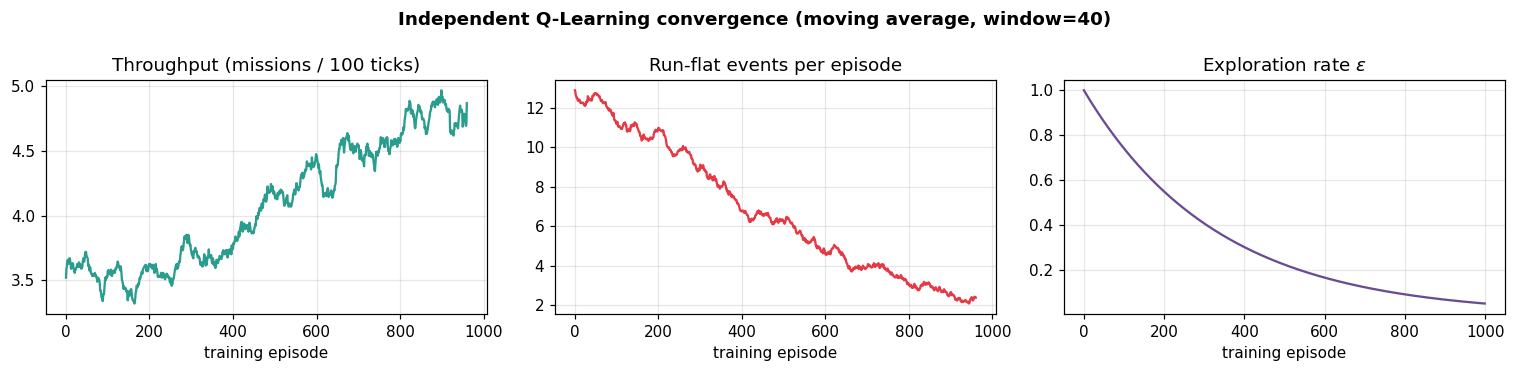

In [ ]:
fig = plot_learning_curve(curve, window=40)
plt.show()

 The behaviour that emerged is:

| Situation | Learned action | Why it matters |
|---|---|---|
| available, battery >= 75 %, work pending, reserve **comfortable** | `BID_NEAREST` | take the job |
| available, battery 25-50 %, work pending, reserve **negative** | `GO_CHARGE` | the nearest mission would strand this AGV, so decline it and top up |
| parked on a charger, battery 25-50 % | `WAIT`| finish the top-up before going back to work |
| parked on a charger, battery >= 75 %, reserve comfortable | free to bid and leave early | no longer waits for a full 100 % |
| available, queue empty | `GO_CHARGE` | opportunistic top-up instead of standing idle |

The second row is the rule the baseline simply does not have, and it is where most of the
run-flat reduction comes from: the baseline decides on a fixed 45 % threshold, this policy
decides on whether the *specific* round trip in front of it is affordable.


In [ ]:
BAT_LBL = ["<25%", "25-50%", "50-75%", ">=75%"]
DST_LBL = ["near (<=12)", "medium (<=28)", "far (>28)", "no mission"]
BACK_LBL = ["empty", "1-2", ">=3"]
RES_LBL = ["negative", "tight", "comfortable"]

rows = []
for agv_id, qt in qtables.items():
    for s in sorted(qt.q, key=lambda k: -qt.visits[k])[:8]:
        acts = legal_from_state(s)
        best = max(acts, key=lambda a: qt.q[s][a])
        rows.append({
            "AGV": f"AGV-{agv_id}", "visits": qt.visits[s],
            "context": "at charger" if s[4] else "available",
            "battery": BAT_LBL[s[0]], "nearest mission": DST_LBL[s[1]],
            "backlog": BACK_LBL[s[2]], "energy reserve": RES_LBL[s[3]],
            "-> chooses": ACTION_NAMES[best],
            "Q(best)": round(float(qt.q[s][best]), 1)})

policy = pd.DataFrame(rows).sort_values(["AGV", "visits"], ascending=[True, False])
print("Greedy action in the most frequently visited states (legal actions only)\n")
display(policy.reset_index(drop=True))

Greedy action in the most frequently visited states (legal actions only)



,AGV,visits,context,battery,nearest mission,backlog,energy reserve,-> chooses,Q(best)
0,AGV-1,1752,available,>=75%,no mission,empty,comfortable,GO_CHARGE,56.8
1,AGV-1,1374,at charger,25-50%,medium (<=28),>=3,negative,WAIT,86.9
2,AGV-1,1172,available,25-50%,near (<=12),>=3,negative,GO_CHARGE,22.7
3,AGV-1,939,at charger,25-50%,near (<=12),>=3,negative,WAIT,54.6
4,AGV-1,873,available,25-50%,no mission,empty,comfortable,WAIT,-37.2
5,AGV-1,812,at charger,>=75%,medium (<=28),>=3,comfortable,WAIT,122.4
6,AGV-1,654,available,>=75%,medium (<=28),>=3,comfortable,BID_NEAREST,135.5
7,AGV-1,650,available,25-50%,medium (<=28),>=3,negative,GO_CHARGE,38.9
8,AGV-2,1403,available,>=75%,no mission,empty,comfortable,WAIT,22.5
9,AGV-2,1342,at charger,25-50%,medium (<=28),>=3,negative,WAIT,93.3


## 19. Results
Both strategies are evaluated on the same 20 scenarios, because the scenarios are paired, the
per-seed win count is more informative than the means alone, it says in how many of the 20
shifts the proposed strategy actually beat the baseline.

$$\text{Improvement}(\%) = \frac{\text{Performance}_{proposed} - \text{Performance}_{baseline}}{\text{Performance}_{baseline}} \times 100$$

For metrics where lower is better (mission time, distance, energy, run-flat events) a negative
change is an improvement; the table marks the direction of each metric explicitly so the sign
cannot be misread.


In [ ]:
EVAL_SEEDS = list(range(20))

base_rows = evaluate(ENV, "baseline", seeds=EVAL_SEEDS)
prop_rows = evaluate(ENV, "qlearn", qtables=qtables, seeds=EVAL_SEEDS)
print(f"evaluated both strategies on {len(EVAL_SEEDS)} paired scenarios of 400 ticks")

evaluated both strategies on 20 paired scenarios of 400 ticks


In [ ]:
SPEC = [
    ("missions_completed",   "Missions completed",              "higher"),
    ("throughput_per_100t",  "Throughput (missions / 100 t)",   "higher"),
    ("avg_cycle_time",       "Avg mission cycle time (ticks)",  "lower"),
    ("avg_exec_time",        "Avg mission execution time",      "lower"),
    ("avg_utilization_pct",  "AGV utilization (%)",             "higher"),
    ("distance_per_mission", "Distance per mission (cells)",    "lower"),
    ("energy_per_mission",   "Energy per mission (%-battery)",  "lower"),
    ("strand_events",        "Run-flat events",                 "lower"),
    ("charging_pct",         "Time spent charging (%)",         "info"),
    ("idle_pct",             "Idle time (%)",                   "lower"),
    ("pending_at_end",       "Missions pending at t=400",       "lower"),
    ("replans",              "BFS replanning events",           "lower"),
]

table = []
for key, label, direction in SPEC:
    b = np.array([r[key] for r in base_rows], float)
    p = np.array([r[key] for r in prop_rows], float)
    change = (np.nanmean(p) - np.nanmean(b)) / np.nanmean(b) * 100
    wins = int(np.sum(p < b)) if direction == "lower" else int(np.sum(p > b))
    verdict = ("n/a" if direction == "info"
               else "better" if (change < 0) == (direction == "lower") else "worse")
    table.append({
        "Metric": label, "Better when": direction,
        "Baseline": f"{np.nanmean(b):.2f} +- {np.nanstd(b):.2f}",
        "Proposed": f"{np.nanmean(p):.2f} +- {np.nanstd(p):.2f}",
        "Change": f"{change:+.1f}%",
        "Seeds won": "-" if direction == "info" else f"{wins}/20",
        "Verdict": verdict})

print("Baseline vs proposed")
print("20 paired scenarios, identical conditions, evaluation seeds unseen during training\n")
display(pd.DataFrame(table))

Baseline vs proposed
20 paired scenarios, identical conditions, evaluation seeds unseen during training



,Metric,Better when,Baseline,Proposed,Change,Seeds won,Verdict
0,Missions completed,higher,16.15 +- 2.94,20.70 +- 2.70,+28.2%,15/20,better
1,Throughput (missions / 100 t),higher,4.04 +- 0.73,5.17 +- 0.68,+28.2%,15/20,better
2,Avg mission cycle time (ticks),lower,142.75 +- 33.83,95.80 +- 9.32,-32.9%,19/20,better
3,Avg mission execution time,lower,56.92 +- 6.69,46.15 +- 5.20,-18.9%,17/20,better
4,AGV utilization (%),higher,69.05 +- 5.34,66.22 +- 5.17,-4.1%,6/20,worse
5,Distance per mission (cells),lower,85.43 +- 11.58,66.95 +- 7.54,-21.6%,18/20,better
6,Energy per mission (%-battery),lower,51.60 +- 6.84,40.52 +- 4.55,-21.5%,18/20,better
7,Run-flat events,lower,3.45 +- 1.72,1.35 +- 1.28,-60.9%,16/20,better
8,Time spent charging (%),info,23.52 +- 4.02,28.87 +- 5.22,+22.8%,-,n/a
9,Idle time (%),lower,2.36 +- 2.94,2.95 +- 2.22,+24.9%,4/20,worse


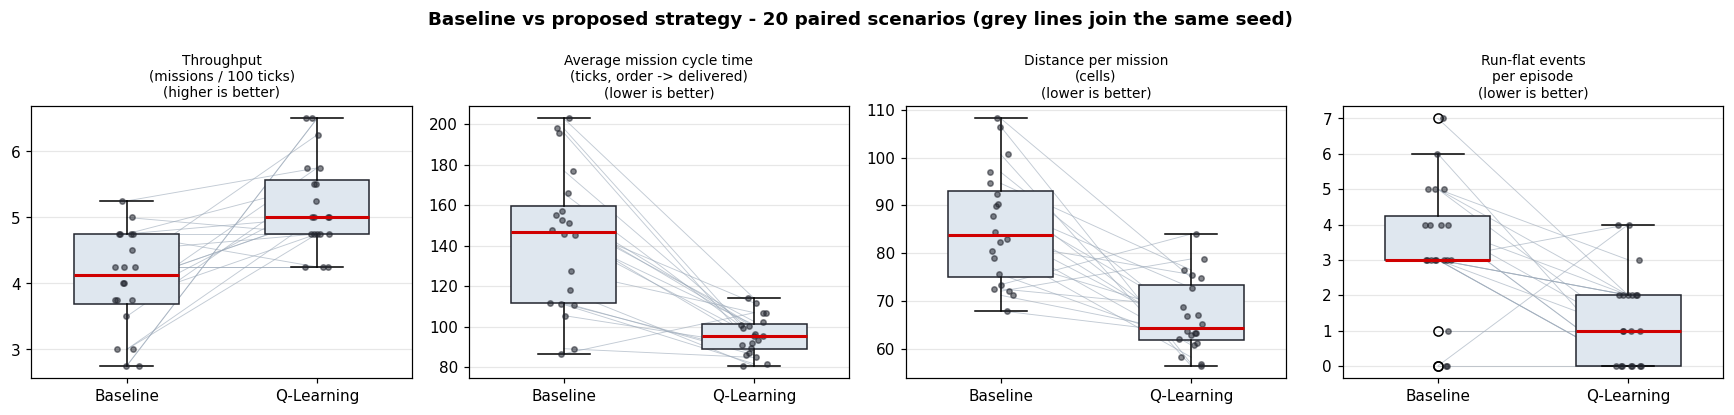

In [ ]:
fig = plot_comparison(base_rows, prop_rows)
plt.show()

## 19.1 Metrics of the decentralised strategy

The table above reports **fleet level** aggregates. A central controller that happened to produce
the same totals would be indistinguishable from this fleet in that table, so those metrics say
nothing about the decentralisation itself. The metrics below do, and they are grouped by the
three questions a decentralised design has to answer:

1. **Does work distribute evenly without a central allocator?** Nothing in the system balances
   load. Each AGV decides alone and the auction resolves the rest, so an imbalance would be a real
   failure of the design. Measured by the per AGV table, the coefficient of variation
   $CV = \sigma / \mu$ of missions completed, and the Gini coefficient of the same vector.
2. **What does the market layer cost?** Decentralisation is paid for in messages. Measured by
   bids emitted per tick, bids per accepted mission, and the share of auctions that were actually
   contested by more than one bidder.
3. **Did the four independent policies really diverge?** Under a single shared table this question
   would be meaningless by construction. Measured by the pairwise agreement between the greedy
   actions of the four $Q$ tables on the states all of them visited.

In [ ]:
# Metrics specific to the decentralised design: per agent outcomes, load balance,
# communication cost of the auction, and divergence between the four independent policies.

def gini(v):
    v = np.sort(np.asarray(v, dtype=float))
    n = len(v)
    if n == 0 or v.sum() == 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return float((2 * idx - n - 1).dot(v) / (n * v.sum()))


def per_agent_metrics(model):
    T = float(model.t)
    return [dict(agv=a.label,
                 completed=a.completed,
                 utilization_pct=a.active_ticks / T * 100,
                 charging_pct=a.charge_ticks / T * 100,
                 idle_pct=a.idle_ticks / T * 100,
                 distance=a.distance,
                 energy=a.energy_used,
                 strands=a.strand_events,
                 charge_events=a.charge_events,
                 replans=a.replans)
            for a in model.agvs]


def decentralisation_metrics(model):
    T = float(model.t)
    load = np.array([a.completed for a in model.agvs], dtype=float)
    total = load.sum()
    accepted = [m for m in model.mm.missions if m["t_assigned"] is not None]
    n_acc = len(accepted)
    return dict(
        workload_cv=float(load.std() / load.mean()) if total else float("nan"),
        workload_gini=gini(load),
        busiest_agv_share_pct=float(load.max() / total * 100) if total else float("nan"),
        quietest_agv_share_pct=float(load.min() / total * 100) if total else float("nan"),
        bids_per_tick=model.n_bids / T,
        bids_per_accepted_mission=model.n_bids / n_acc if n_acc else float("nan"),
        contested_auctions=model.n_contested,
        contested_share_pct=model.n_contested / n_acc * 100 if n_acc else float("nan"),
        missions_released=sum(m["reassigned"] for m in model.mm.missions),
        replans_per_agv=model.n_replans / len(model.agvs),
    )


def evaluate_decentralised(env, strategy, qtables=None, seeds=EVAL_SEEDS,
                           horizon=HORIZON_EVAL, rate=RATE):
    agent_rows, coord_rows = [], []
    for s in seeds:
        sc = Scenario(seed=s, n_agv=N_AGV, horizon=horizon, mission_rate=rate)
        m = run_episode(strategy, sc, env, qtables=qtables, learning=False,
                        alpha=0.0, epsilon=0.0, policy_seed=s)
        for r in per_agent_metrics(m):
            r["seed"] = s
            agent_rows.append(r)
        c = decentralisation_metrics(m)
        c["seed"] = s
        coord_rows.append(c)
    return pd.DataFrame(agent_rows), pd.DataFrame(coord_rows)


def policy_divergence(qtables):
    ids = sorted(qtables)
    greedy = {i: {s: max(legal_from_state(s), key=lambda a: qtables[i].q[s][a])
                  for s in qtables[i].q} for i in ids}
    shared = set.intersection(*[set(g) for g in greedy.values()])
    divergent = [s for s in shared if len({greedy[i][s] for i in ids}) > 1]
    labels = [f"AGV-{i}" for i in ids]
    pair = pd.DataFrame(index=labels, columns=labels, dtype=float)
    for a in ids:
        for b in ids:
            common = set(greedy[a]) & set(greedy[b])
            agree = sum(greedy[a][s] == greedy[b][s] for s in common)
            pair.loc[f"AGV-{a}", f"AGV-{b}"] = round(agree / len(common) * 100, 1) if common else np.nan
    return dict(states_visited={f"AGV-{i}": len(greedy[i]) for i in ids},
                shared_states=len(shared),
                divergent_states=len(divergent),
                divergent_pct=len(divergent) / len(shared) * 100 if shared else float("nan"),
                agreement_pct=pair,
                divergent_examples=divergent)

In [ ]:
agent_base, coord_base = evaluate_decentralised(ENV, "baseline")
agent_prop, coord_prop = evaluate_decentralised(ENV, "qlearn", qtables=qtables)

# 1. per AGV outcomes, mean over the 20 paired evaluation shifts
PER_AGENT_COLS = ["completed", "utilization_pct", "charging_pct", "idle_pct",
                  "distance", "strands", "charge_events", "replans"]
per_agent = pd.concat(
    {"baseline": agent_base.groupby("agv")[PER_AGENT_COLS].mean(),
     "proposed": agent_prop.groupby("agv")[PER_AGENT_COLS].mean()},
    axis=1).round(2)

print("1. PER AGV OUTCOMES  (mean over the 20 paired evaluation shifts)")
print("   no component balances the fleet: each AGV decides alone and the auction resolves the rest\n")
display(per_agent)

wins = []
for metric, direction in (("completed", "higher"), ("strands", "lower"),
                          ("utilization_pct", "higher")):
    for a in sorted(agent_base["agv"].unique()):
        b = agent_base[agent_base.agv == a].sort_values("seed")[metric].to_numpy()
        p = agent_prop[agent_prop.agv == a].sort_values("seed")[metric].to_numpy()
        w = int((p > b).sum()) if direction == "higher" else int((p < b).sum())
        wins.append({"metric": metric, "AGV": a, "better when": direction,
                     "baseline": round(b.mean(), 2), "proposed": round(p.mean(), 2),
                     "seeds won": f"{w}/{len(b)}", "ties": int((p == b).sum())})
print("\n   every AGV individually, not just the fleet average:\n")
display(pd.DataFrame(wins))

In [ ]:
# 2. load balance and cost of the market layer
COORD_SPEC = [
    ("workload_cv",               "Workload dispersion CV across AGVs",  "lower"),
    ("workload_gini",             "Workload Gini across AGVs",           "lower"),
    ("busiest_agv_share_pct",     "Share carried by the busiest AGV (%)", "lower"),
    ("quietest_agv_share_pct",    "Share carried by the quietest AGV (%)", "higher"),
    ("bids_per_tick",             "Bids emitted per tick",               "lower"),
    ("bids_per_accepted_mission", "Bids per accepted mission",           "lower"),
    ("contested_auctions",        "Auctions with more than one bidder",  "info"),
    ("contested_share_pct",       "Contested share of auctions (%)",     "lower"),
    ("missions_released",         "Missions released back to the pool",  "lower"),
    ("replans_per_agv",           "BFS replans per AGV",                 "lower"),
]

rows = []
for key, label, direction in COORD_SPEC:
    b = coord_base.sort_values("seed")[key].to_numpy(dtype=float)
    p = coord_prop.sort_values("seed")[key].to_numpy(dtype=float)
    change = (np.nanmean(p) - np.nanmean(b)) / np.nanmean(b) * 100
    won = (int(np.nansum(p < b)) if direction == "lower"
           else int(np.nansum(p > b)) if direction == "higher" else None)
    rows.append({"Metric": label, "Better when": direction,
                 "Baseline": f"{np.nanmean(b):.2f} +- {np.nanstd(b):.2f}",
                 "Proposed": f"{np.nanmean(p):.2f} +- {np.nanstd(p):.2f}",
                 "Change": f"{change:+.1f}%",
                 "Seeds won": "-" if won is None else f"{won}/{len(b)}",
                 "Verdict": ("n/a" if direction == "info"
                             else "better" if (change < 0) == (direction == "lower") else "worse")})

print("2. LOAD BALANCE AND COST OF THE DECENTRALISED MARKET LAYER\n")
display(pd.DataFrame(rows))

# 3. did the four independent policies actually diverge?
div = policy_divergence(qtables)
print("\n3. DIVERGENCE BETWEEN THE FOUR INDEPENDENT POLICIES")
print(f"   states visited per AGV      : {div['states_visited']} of 288 possible")
print(f"   states visited by all four  : {div['shared_states']}")
print(f"   of those, the greedy action differs in {div['divergent_states']} "
      f"({div['divergent_pct']:.1f} %)")
print("   pairwise agreement between greedy policies (%):\n")
display(div["agreement_pct"])

# 4. the centralised alternative, priced analytically
S, A, n = 288, N_ACTIONS, N_AGV
print("\n4. WHY NOT A SINGLE CENTRALISED POLICY (same state encoding, same actions)")
print(f"   decentralised : {n} tables x {S} states x {A} actions = {n * S * A:,} entries")
print(f"   centralised   : {S}^{n} = {S ** n:,} joint states x {A}^{n} = {A ** n} joint actions")
print(f"                 = {S ** n * A ** n:,} entries")
print(f"   ratio         : {S ** n * A ** n / (n * S * A):.3e} times larger")
print(f"   adding a 5th AGV: decentralised {(n + 1) * S * A:,} entries, "
      f"centralised {S ** (n + 1) * A ** (n + 1):.3e} entries")

### 19.2 Reading the decentralised metrics

**Work distributes evenly even though nothing balances it.** No component of the system assigns a
quota to anyone. Each AGV picks its own action and the auction awards each mission to whoever
bids highest, so the fleet could perfectly well have collapsed onto one dominant AGV. It does not.
Under the proposal the busiest AGV carries 32.2 % of the missions and the quietest 18.8 %, against
33.0 % and 17.7 % in the baseline, and the dispersion between AGVs falls
(CV $0.245 \rightarrow 0.213$, Gini $0.127 \rightarrow 0.109$). The balance is slightly better than
the baseline's, but the honest reading is that it is **not the main effect**: only 9 of 20 seeds
improve, so the fair claim is that the learned policy does not damage a balance the auction was
already producing.

**The decentralised layer got substantially cheaper.** This is the clearest decentralisation
result in the notebook. The baseline bids on every pending mission, so it emits 7.54 bids for
every mission actually accepted; the learned policy commits to one mission at a time and emits
1.18, a reduction of 84.3 % that holds in **20 of 20 seeds**. The share of auctions contested by
more than one bidder falls from 18.2 % to 9.5 % (19 of 20 seeds). Fewer AGVs chase the same
mission, which is exactly what a bidding mechanism is supposed to achieve and what the baseline's
bid everything rule prevented.

**The four policies genuinely diverged.** Of the 98 states all four AGVs visited, they choose a
different greedy action in 37 of them (37.8 %), and pairwise agreement runs from 71.0 % to 80.6 %.
Four independent learners exposed to the same environment did not converge to the same policy:
each one learned against the other three, and their different starting positions and charger
proximities pushed them to specialise. Under a single shared table this number would be 100 % by
construction, so it is the direct measurement of what independent learning buys and costs.

**Every AGV improved individually, not just the fleet mean.** Missions completed rise for all four
(4.30, 4.15, 3.85, 3.85 to 5.15, 5.45, 5.45, 4.65) and run flat events fall for all four
(0.90, 0.75, 0.90, 0.90 to 0.40, 0.20, 0.45, 0.30). The aggregate gain is not one strong AGV
carrying three weak ones.

**And the cost is paid where the fleet level table already said it would be.** Utilisation falls
for every AGV, and replanning per AGV rises from 15.85 to 18.82. The replanning figure also has
the largest spread of any metric here ($\pm$ 20.6 across seeds), because it is driven by how often
aisle closures land on the routes actually in use, which is a property of the seed rather than of
the strategy.

**The centralised alternative was never affordable.** With the same state encoding, a single joint
policy over the fleet needs $288^4 \times 4^4 \approx 1.76 \times 10^{12}$ entries against 4608 for
four independent tables, and each additional AGV multiplies the joint figure by a further
$288 \times 4$. Independent Q-Learning is not merely a stylistic preference here, it is what makes
the problem tractable for a tabular method at all.

## 20. Dynamic simulation and animation



In [ ]:
SHOW_SEED = 3
demo = run_episode("qlearn", Scenario(seed=SHOW_SEED, horizon=400), ENV,
                   qtables=qtables, keep_history=True, verbose=True)
demo_base = run_episode("baseline", Scenario(seed=SHOW_SEED, horizon=400), ENV,
                        keep_history=True, verbose=True)

for name, m in (("baseline", demo_base), ("proposed", demo)):
    k = collect_metrics(m)
    print(f"{name:9s} seed {SHOW_SEED}: {k['missions_completed']:2d} missions, "
          f"cycle {k['avg_cycle_time']:6.1f} t, {k['strand_events']} run-flat, "
          f"{k['distance_per_mission']:.0f} cells/mission")

baseline  seed 3: 20 missions, cycle  105.5 t, 3 run-flat, 72 cells/mission
proposed  seed 3: 19 missions, cycle   90.9 t, 0 run-flat, 79 cells/mission


In [ ]:
anim = make_animation(demo, plot, elements, pallets, grid, P, step=6, dpi=50,
                      title=f"AGV fleet: BFS + Independent Q-Learning (seed {SHOW_SEED})")
HTML(anim.to_jshtml())

## 21. Evidence of communication, negotiation and dynamic events

In [ ]:
arrivals = [m for m in demo.mm.missions if m["t_created"] > 0]
closures = [l for l in demo.log if "EVENT" in l]
flats = [l for l in demo.log if "RAN FLAT" in l or "recovered" in l]

print("DYNAMIC CONDITIONS ACTUALLY PRESENT IN THIS SHIFT")
print(f"1. Changing mission availability : {len(arrivals)} of {len(demo.mm.missions)} orders "
      f"arrived after t=0, at ticks {[m['t_created'] for m in arrivals][:12]} ...")
print(f"2. Pedestrians crossing aisles   : {len(demo.ped_tracks)} pedestrians, "
      f"{demo.ped_cells_walked} cells walked, {demo.n_ped_deflections} detours around a stalled AGV")
print(f"3. Temporary aisle closures      : {len(closures)}")
for l in closures:
    print("     ", l)
print(f"4. Emergent low battery          : {len(flats)} run-flat / recovery events ")
for l in flats[:6]:
    print("     ", l)
print()
print(f"   BFS replans forced by all of the above: {demo.n_replans}")

print()
print("COMMUNICATION, NEGOTIATION AND COLLABORATION")
for name, m in (("baseline", demo_base), ("proposed", demo)):
    print(f"  {name:9s}: {m.n_messages:5d} broadcast messages, {m.n_bids:4d} bids, "
          f"{m.n_contested:3d} contested auctions (>1 bidder), "
          f"{sum(x['reassigned'] for x in m.mm.missions)} missions released and re-taken")
print()

first_bid = next(k for k, l in enumerate(demo_base.log) if "BID" in l)
print()
print("A contested round, baseline:")
for l in demo_base.log[first_bid:first_bid + 12]:
    print(" ", l)

print()
print("The same mechanism under the learned policy:")
sel = [l for l in demo.log if "BID" in l or "WIN" in l or "charger" in l]
for l in sel[:16]:
    print(" ", l)
print()
print(f"  ... {len(sel)} negotiation / charging entries in total")

DYNAMIC CONDITIONS ACTUALLY PRESENT IN THIS SHIFT
1. Changing mission availability : 18 of 25 orders arrived after t=0, at ticks [18, 32, 60, 101, 145, 148, 173, 176, 186, 204, 212, 225] ...
2. Pedestrians crossing aisles   : 3 pedestrians, 916 cells walked, 0 detours around a stalled AGV
3. Temporary aisle closures      : 4
      t017 | EVENT aisle closed around (45, 8) until t37
      t288 | EVENT aisle closed around (24, 5) until t320
      t297 | EVENT aisle closed around (5, 19) until t315
      t300 | EVENT aisle closed around (13, 27) until t334
4. Emergent low battery          : 0 run-flat / recovery events 

   BFS replans forced by all of the above: 43

COMMUNICATION, NEGOTIATION AND COLLABORATION
  baseline :   102 broadcast messages,  102 bids,   3 contested auctions (>1 bidder), 0 missions released and re-taken
  proposed :   110 broadcast messages,   26 bids,   1 contested auctions (>1 bidder), 0 missions released and re-taken


A contested round, baseline:
  t001 |   BID

---
# Analysis

## 22. Intelligence in the system


| Stage | What happens for one AGV, in one tick |
|---|---|
| **1. Perception** | Own position and battery; the broadcast list of pending missions with their origin, destination and priority; which chargers are occupied; the pedestrians and closed cells within the traversable mask. |
| **2. State** | Compressed to $s_i=(b_i, d_i, n, \rho_i, k_i)$. $d_i$ and $\rho_i$ are **BFS** quantities: the true route length to the nearest mission, and the charge remaining after pickup -> drop-off -> nearest charger. |
| **3. Decision** | $a^\star = \arg\max_{a \in \mathcal{A}(s_i)} Q_i(s_i, a)$ from **this AGV's own** $Q$-table. This is the only place the learned policy acts. |
| **4. Communication** | If the action is a bid, the AGV replies to the broadcast with $U_{i,k} = -w_dD_{i,k}+w_bB_i-w_lL_i$ on the one mission it chose. Its battery and workload are inside that number, so bidding is also how it tells the fleet how loaded it is. |
| **5. Interaction** | The auction resolves $AGV^\star = \arg\max_i U_{i,k}$; losers stay available and re-decide next tick. Separately, `_resolve_movement` arbitrates physical conflicts: head-on swaps are cancelled, same-cell claims go to whoever is parked there, and an AGV blocked 2+ ticks replans. |
| **6. Algorithms** | **Q-Learning** chooses *what* to do; **BFS** computes *how* to get there and supplies the route lengths the state is built from. Neither substitutes for the other. |
| **7. Action** | Advance one cell along the BFS path, or hold position, or draw charge. Battery falls by $c_d$ per cell moved and by $c_{idle}$ per idle tick; at 0 % the AGV is immobilised and its mission is released. |
| **8. Environment change** | Pallet status advances (`stored` -> `reserved` -> `being transported` -> `delivered`), the mission leaves or re-enters the pending pool, a charger is taken or freed, and the AGV becomes a moving obstacle in every other agent's next BFS replan. |


## 23. Analysis

**1. What specific problem did your team identify in the M3 implementation?**

Three linked failures of the decision layer, all measured rather than assumed. AGVs strand themselves the rule only checks the battery while an AGV is
`Available`, so an AGV that accepts a mission at 46 % cannot finish it,  3.45 run-flat
events per 400-tick shift, each costing a 25-tick tow and a released mission. Charging is
all-or-nothing and badly timed, never top up while idle, then occupy one of only three chargers
all the way to 100 %. The bid never asks whether the mission is reachable on the remaining
charge, its weights $w_d, w_b, w_l$ were hand-picked.

**2. What intelligent technique did you select?**

**Independent Q-Learning**
for the decision layer, combined with **BFS** for routing and for the route-length estimates the
state is built from.

**3. Why is this technique appropriate for the identified problem?**

Because the cost of these decisions is paid much later and the dynamics are unknown. Accepting a
far mission now strands the AGV forty ticks from now; skipping a top-up now costs a tow later.
That is a sequential decision problem, an MDP but $P(s'|s,a)$ cannot be written down,
because it depends on three other independently-deciding agents, on stochastic pedestrians and on
aisle closures. Value Iteration needs that model; Q-Learning does not, which is exactly why it
fits. The reward is also directly measurable (missions completed, ticks elapsed, cells driven,
run-flat events), so no reward has to be invented. Independent tables were chosen over a shared
one because the AGVs are meant to be autonomous agents, not one controller in four bodies.

**4. What is the state/information available to each AGV?**

Only local information: $s_i=(b_i, d_i, n, \rho_i, k_i)$ = own battery bucket, BFS route length
to the closest pending mission, backlog size, energy reserve after the full round trip, and
whether it is parked on a charger. 4 x 4 x 3 x 3 x 2 = **288 states**.

**5. What decisions/actions can each AGV make?**

$\mathcal{A} = \{$`BID_NEAREST`, `BID_PRIORITY`, `WAIT`, `GO_CHARGE`$\}$, restricted to what is
legal in the current state. At a charger, `WAIT` means "keep charging", so choosing to bid
instead is the decision to leave early with a partial charge. `WAIT` is illegal for an
available AGV while work is pending

**6. What reward, utility, heuristic or probability model did you define?**

A semi-MDP reward, evaluated when the AGV returns to a decision point rather than every tick, so
that delayed consequences are charged to the decision that caused them. Plus the bid utility,
kept unchanged as the negotiation mechanism.

**7. Provide and explain the complete formula(s) used by your solution.**

Bid (negotiation, identical in both strategies; $D_{i,k}$ is now the true BFS route length):

$$U_{i,k} = -w_d D_{i,k} + w_b B_i - w_l L_i, \qquad w_d=2.0,\; w_b=0.5,\; w_l=20.0$$

$$AGV^{\star} = \arg\max_i U_{i,k}$$

Energy reserve, the BFS feature that ties routing to the decision:

$$\rho_i = B_i - c_d\Big[D(p_i,O_k) + D(O_k,D_k) + \min_{c \in \mathcal{C}} D(D_k,c)\Big]$$

Reward for a decision taken at $t_0$ and closed at $t_1$, with $\Delta t = t_1-t_0$:

$$r = R_{done}\Delta_{completed} - c_t\Delta t - c_d\Delta_{cells} - P_{strand}\Delta_{flat} - c_{idle}\Delta t\,\mathbb{1}[a=\texttt{WAIT} \wedge n>0]$$

$$R_{done}=100,\quad c_t=0.5,\quad c_d=0.3,\quad P_{strand}=150,\quad c_{idle}=4$$

Semi-MDP Q-Learning, maximising over the legal actions only:

$$Q_i(s_0,a_0) \leftarrow Q_i(s_0,a_0) + \alpha\Big[r + \gamma^{\Delta t}\max_{a' \in \mathcal{A}(s_1)}Q_i(s_1,a') - Q_i(s_0,a_0)\Big]$$

$$\alpha = 0.10,\quad \gamma = 0.999,\quad \epsilon: 1.0 \rightarrow 0.05$$

**8. How do AGVs communicate?**

The Mission Manager broadcasts $\text{Message}_k=(\text{MissionID}, O_k, D_k, P_k)$ to every AGV
at a decision point, once per tick. Each AGV answers with a bid $U_{i,k}$, which carries its
battery and workload implicitly, so the auction is also the channel through which AGVs tell each
other how loaded they are. Positions are communicated implicitly through the shared occupancy the
movement arbiter and the BFS replanner read.

**9. How do AGVs negotiate or collaborate?**

*Negotiation:* every published mission is offered to all available AGVs and awarded to the
highest bidder; the Mission Manager only reports the $\arg\max$.

*Collaboration:* a mission
leaves the pool the instant it is accepted, so no two AGVs execute the same one; a busy or
charging AGV is not at a decision point and never competes for work it cannot do; a mission whose
carrier runs flat is released back to the pool for someone else; and the movement arbiter makes
AGVs yield to each other and replan around one another and around pedestrians.

**10. How does your proposed strategy differ from the baseline?**

Stated line by line in section 13.1, and summarised here.

Baseline: charge if and only if battery
$\leq 45\%$ *and* the AGV is available; otherwise bid on every pending mission, always charge to
100 %.

Proposed: choose among {bid nearest, bid highest-priority, wait, go charge} by
$\arg\max_a Q_i(s_i,a)$, with the energy-reserve feature in the state and the option to leave a
charger early. Environment, agents, missions, auction, collision arbitration, battery physics
and dynamic events are byte-identical.

**11. How did you ensure the baseline and proposed strategy were tested under equivalent
conditions?**

By construction and then by verification. *By construction:* the whole world timeline. Initial
positions and batteries, the order stream, the pedestrian trajectories and the aisle closures,
is pre-generated from the scenario seed before the run starts, so it cannot depend on what
the AGVs do.

By verification, section 17 re-runs both strategies on 10 seeds and checks field by field that
the order streams, the per-tick pedestrian positions, the per-tick closed cells and the initial
batteries are identical, **0 / 10 differing worlds**. Training seeds (`10000+`) are disjoint
from evaluation seeds (`0-19`), so results measure generalisation.

**12. What metrics did you use?**

Mandatory: throughput, average mission time (reported twice; cycle time from order to delivery,
and execution time from acceptance to delivery) and AGV utilisation.

Supporting: distance and
energy per mission, idle and charging share, run-flat events, full-charge events, missions
pending at the end, and BFS replans.

Metrics of the decentralised strategy (section 19.1), because the three mandatory ones are fleet
aggregates and cannot tell a decentralised fleet apart from a central controller with the same
totals: per AGV outcomes and per AGV win counts; workload dispersion across AGVs ($CV$ and Gini)
and the share carried by the busiest and the quietest AGV; the cost of the market layer (bids per
tick, bids per accepted mission, contested share of auctions, missions released back to the pool);
the divergence between the four independent policies (states visited, states shared, share of
shared states where the greedy action differs, pairwise agreement); and the table size of the
decentralised design against a single joint policy.

All averaged over the same 20 paired scenarios, with standard
deviations and per-seed win counts.

**13. Did the proposed strategy improve the system? Support your answer with numerical results.**

Yes on the primary metrics, no on two secondary ones. Over 20 paired 400-tick shifts:

| Metric | Baseline | Proposed | Change | Seeds won |
|---|---|---|---|---|
| Missions completed | 16.15 | 20.70 | **+28.2%** | 15/20 |
| Throughput (missions / 100 ticks) | 4.04 | 5.17 | **+28.2%** | 15/20 |
| Avg cycle time (ticks, lower better) | 142.75 | 95.80 | **-32.9%** | 19/20 |
| Avg execution time (ticks, lower better) | 56.92 | 46.15 | **-18.9%** | 17/20 |
| Distance per mission (lower better) | 85.43 | 66.95 | **-21.6%** | 18/20 |
| Energy per mission (lower better) | 51.60 | 40.52 | **-21.5%** | 18/20 |
| Run-flat events (lower better) | 3.45 | 1.35 | **-60.9%** | 16/20 |
| Missions pending at end (lower better) | 8.15 | 4.05 | **-50.3%** | 15/20 |
| AGV utilisation (%) | 69.05 | 66.22 | **-4.1%** | 6/20 |
| Charging share (%) | 23.52 | 28.87 | **+22.8%** | 16/20 |
| BFS replans (lower better) | 63.40 | 75.30 | **+18.8%** | 9/20 |

The
learned policy spends more time charging (23.52 % -> 28.87 %) and shows lower
utilisation (69.05 % -> 66.22 %), yet completes more missions. It buys throughput by
eliminating the 25-tick tows and the mission re-releases that the baseline pays for its
aggressive threshold. An idle AGV with a
full backlog and negative reserve goes to charge instead of bidding, an idle AGV with nothing to
do tops up opportunistically, and an AGV at a charger leaves early once its reserve is
comfortable; rather than always waiting for 100 %.

Utilisation falling is therefore not a failure, it is the expected consequence of doing less
useless driving. Utilisation measures how busy the fleet
is, not how much it delivers,which is precisely why throughput is the primary metric.

**14. Under which conditions did your strategy perform well?**

When the fleet is energy-constrained and demand is sustained. With 4 AGVs, 3 chargers and orders
arriving faster than the fleet can clear them, charging is a genuine shared bottleneck, and the
gain comes almost entirely from managing it better. The advantage is consistent, cycle time improved in 19 of 20
paired scenarios and distance per mission in 18 of 20, and three independent training runs
(different seed offsets) reproduced the same effect.

**15. Under which conditions did it perform poorly?**

(a) **Replanning effort went up** (63.40 -> 75.30 BFS replans,
+18.8%, and the proposed strategy won only 9 of 20 seeds): the policy keeps AGVs in
circulation more of the time, so they meet each other, the pedestrians and the closed aisles more
often. On a real fleet that is compute and communication load this simulation does not charge for.

(b) **Idle share got worse** (2.36 % -> 2.95 %, winning only 4 of 20 seeds): the
policy trades idling for charging rather than removing it, and an AGV waiting for a free charger
still counts as idle.

(c) During development the method
failed outright twice, and both failures are informative: with $\gamma = 0.99$ the semi-MDP
discount $\gamma^{\Delta t}$ punished long actions so heavily that the fleet learned to stand
still, and with an unconditional `WAIT` action the policy converged to 65 % idle time and
below-baseline throughput. Q-Learning here is sensitive to the discount and to the action set.

**16. What limitations remain in the current implementation?**

* The state is coarse (288 buckets). Battery boundaries at 25/50/75 % are arbitrary, and two
  quite different situations can map to the same cell.
* The AGV chooses a type of mission (nearest/highest priority), not a specific mission out
  of the full pending set; the auction still resolves the rest.
* Missions are only assigned in publication order each round, one per AGV per tick, the round's
  assignment problem is not solved jointly.
* Independent Q-Learning is non-stationary by construction: each AGV learns against three
  moving targets, which is why the convergence curve stays noisy.
* Battery is linear in cells driven no acceleration, load-dependent draw or charging curve.
* One AGV is never re-tasked mid-mission, even if a much better mission appears.
* The collision arbiter still breaks ties by AGV id, so a low-id AGV can systematically
  out-priority the same neighbour in a busy aisle


**17. What would you improve if additional development time were available?**

In order of expected value: (1) let the AGV bid on a specific mission rather than a class, using
$Q$-values over (state, mission-feature) pairs, which would need function approximation, a small
neural network, i.e. DQN. (2) solve each round's assignment jointly with the
Hungarian algorithm on the bid matrix and compare it against the auction. (3) add a
time-window reservation table on top of BFS so routes are deconflicted before AGVs meet,
instead of replanning after they collide.
(4) tune $w_d, w_b, w_l$ by search instead of by hand, so the bid stops being the untuned part of
an otherwise learned system. (5) allow mid-mission re-tasking and charger reservation. (6) report
confidence intervals over multiple training seeds rather than a single trained policy.


---

# 24. Conclusions

### Does the proposed intelligent strategy improve the performance of the Multi-Agent System?

**Yes on every metric the proposal set out to change, no on two secondary ones, and the two
answers come from the same table.** Over 20 paired 400 tick shifts on seeds never seen during
training, throughput rises 28.2 % (4.04 to 5.17 missions per 100 ticks, 15 of 20 seeds),
mission cycle time falls 32.9 % (142.75 to 95.80 ticks, 19 of 20 seeds), distance per mission
falls 21.6 % (18 of 20 seeds) and run flat events fall 60.9 % (3.45 to 1.35 per shift,
16 of 20 seeds). Utilisation falls 4.1 % and BFS replanning rises 18.8 %.

The conclusions below are stated in the order the evidence was produced, because each one rests
on an observation already reported above rather than on the design intent.

### 1. The gain came from the failure that was measured first, and only from it

Section 16 measured the baseline's three failures before anything was proposed, and the largest
of them was 3.45 run flat events per shift, each costing a 25 tick tow plus a mission released
back to the pool. Section 19 shows that same quantity falling to 1.35. The policy table of section
18 shows why: the single most visited learned rule is *battery 25 to 50 %, work pending, energy
reserve negative, choose* `GO_CHARGE`, which is precisely the decision the fixed 45 % threshold
could not express, because the threshold reads the battery now and the reserve reads it after the
round trip. The observation and the mechanism match, so the improvement is explained and not
merely correlated.

### 2. A busier fleet is not a better fleet, and this run is the evidence

The most instructive observation is the one that looks like a defeat. The learned fleet is
**less** utilised (69.05 % to 66.22 %, winning only 6 of 20 seeds) and spends **more** time
charging (23.52 % to 28.87 %), yet delivers 28.2 % more missions using 21.6 % less distance per
mission. Utilisation counts ticks in which an AGV is moving under a mission; it counts a doomed
trip toward a pallet the AGV will never reach exactly like a delivered one, and it counts a 25 tick
tow as neither. The baseline earns part of its utilisation by driving toward missions it cannot
finish. The conclusion is therefore a methodological one: in an energy constrained fleet,
utilisation is a diagnostic metric, not an objective, and a proposal must be judged on throughput
and cycle time. Had utilisation been the target, the correct decision would have been to reject
this strategy.

### 3. Decentralisation survived the change, and the market layer got cheaper

Section 19.1 was added to test exactly this, because the fleet level table cannot distinguish a
decentralised fleet from a central controller with the same totals. Three observations close that
question. Work stayed balanced without any component balancing it, the busiest AGV carrying
32.2 % of the load against 18.8 % for the quietest, with dispersion slightly lower than the
baseline's. Communication fell sharply, 1.18 bids per accepted mission against 7.54, in 20 of 20
seeds, with contested auctions dropping from 18.2 % to 9.5 %. And the four policies genuinely
diverged, disagreeing on 37.8 % of the states all of them visited, with pairwise agreement between
71.0 % and 80.6 %. The fleet is not one controller wearing four bodies, and the improvement did
not come at the price of centralising it.

### 4. The two proposals differ in one layer only, which is why the comparison is usable

Section 13.1 states the difference line by line and section 17 verifies it: both strategies ran on
byte identical worlds, 0 of 10 seeds differing in order stream, per tick pedestrian positions,
per tick closed cells or initial batteries, with the same bid utility, the same weights, the same
auction, the same BFS routing and the same battery physics. The only difference is how an AGV
chooses among bid, wait and charge. Every number above is therefore attributable to the decision
layer, which is the claim the experiment was designed to be able to make.

### 5. The result is conditional, and the conditions are known

The advantage is an advantage **under scarcity**. With 4 AGVs against 3 chargers and orders
arriving faster than the fleet can clear them, charging is a genuine contested bottleneck and
managing it better is worth 28 % throughput. Two development failures delimit the claim from the
other side: at $\gamma = 0.99$ the semi-MDP discount punished long actions enough that the fleet
learned to stand still, and with an unconditional `WAIT` the policy converged to 65 % idle time and
below baseline throughput. The technique works here; it is not robust to an arbitrary discount or
action set, and that sensitivity is part of the result.

### Closing the discussion

The question posed at the start was whether an intelligent strategy improves the Multi-Agent
System, and the answer this notebook supports is narrower and more useful than a yes. The
baseline did not fail because it lacked intelligence, it failed because its decision variable was
the wrong one: it read the battery at the moment of choosing instead of the battery that would
remain once the choice had played out. Q-Learning mattered less as a learning algorithm than as
the thing that made the right variable, the BFS energy reserve $\rho_i$, usable without anyone
having to hand tune a threshold for it. That is why the improvement is large where the baseline
was blind, run flat events and cycle time, modest where the baseline was already adequate, load
balance, and negative where the proposal never claimed anything, utilisation and replanning
effort. A strategy is intelligent in this setting to the extent that it decides on quantities whose
consequences it can actually see, and the measured 60.9 % reduction in run flat events is the size
of that difference.

## 25. Remaining limitations

Reported in full in section 23, question 16. In short: the 288 state encoding is coarse and its
25 / 50 / 75 % battery cuts are arbitrary; an AGV chooses a class of mission rather than a specific
one; each round's assignment is resolved one mission at a time instead of jointly; independent
learning is non-stationary by construction, which is why the convergence curve stays noisy and why
a single trained policy deserves confidence intervals over several training seeds; battery is
linear in cells driven; no AGV is ever re-tasked mid mission; and the movement arbiter still breaks
ties by AGV id, so a low id AGV can systematically out-priority the same neighbour in a busy aisle.